In [1]:
import sys

print(sys.executable)

c:\Users\playdata2\SKN34-2nd-5Team\venv\Scripts\python.exe


In [2]:
import numpy as np
import scipy
import sklearn

from sklearn.base import clone

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("scikit-learn import 성공")

NumPy: 1.26.4
SciPy: 1.12.0
scikit-learn: 1.4.2
scikit-learn import 성공


In [3]:
# 기본 모델링 환경 구성
# 1. 라이브러리

from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42

In [4]:
# 2. 프로젝트 루트 탐색

current_path = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        path
        for path in [
            current_path,
            *current_path.parents
        ]
        if (
            path
            / "data"
            / "processed"
        ).exists()
    ),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "data/processed 폴더를 기준으로 "
        "프로젝트 루트를 찾지 못했습니다."
    )

MODEL_DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "modeling_dataset_rolling_v02.parquet"
)

REPORT_TABLE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

REPORT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BASELINE_RESULT_PATH = (
    REPORT_TABLE_DIR
    / "baseline_validation_results_v02.csv"
)

print(
    "프로젝트 루트:",
    PROJECT_ROOT
)

print(
    "모델링 데이터:",
    MODEL_DATASET_PATH.exists()
)

프로젝트 루트: C:\Users\playdata2\SKN34-2nd-5Team
모델링 데이터: True


In [5]:
# 3. 최종 모델링 데이터 불러오기

modeling_df = pd.read_parquet(
    MODEL_DATASET_PATH
)

print(
    "데이터 크기:",
    modeling_df.shape
)

print(
    "고유 표본:",
    modeling_df[
        "sample_id"
    ].nunique()
)

display(
    modeling_df[
        "churn"
    ].value_counts()
)

데이터 크기: (21601, 89)
고유 표본: 21601


churn
0    18215
1     3386
Name: count, dtype: int64

In [6]:
# 4. 식별자·연도·정답·분할 컬럼은 모델 입력에서 제외

non_feature_columns = {
    "sample_id",
    "user_id",
    "selection_year",
    "observation_year",
    "target_year",
    "churn",
    "experiment_a_split",
    "experiment_b_split"
}

feature_columns = [
    column
    for column in modeling_df.columns
    if column not in non_feature_columns
]

print(
    "모델 피처 수:",
    len(feature_columns)
)

print(
    "정답 컬럼:",
    "churn"
)


모델 피처 수: 81
정답 컬럼: churn


In [7]:
# 5. 모든 모델 피처가 수치형인지 확인

non_numeric_feature_columns = (
    modeling_df[
        feature_columns
    ]
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

print(
    "비수치형 피처:",
    non_numeric_feature_columns
)

assert not non_numeric_feature_columns
assert len(feature_columns) == 81

print("모델 입력 피처 검증 통과")

비수치형 피처: []
모델 입력 피처 검증 통과


In [8]:
# 6. 실험별 Train·Validation·Test 생성 함수

def make_temporal_split(
    dataframe,
    split_column
):
    train_df = dataframe[
        dataframe[
            split_column
        ].eq("train")
    ].copy()

    validation_df = dataframe[
        dataframe[
            split_column
        ].eq("validation")
    ].copy()

    test_df = dataframe[
        dataframe[
            split_column
        ].eq("test")
    ].copy()

    X_train = train_df[
        feature_columns
    ]

    y_train = train_df[
        "churn"
    ]

    X_validation = validation_df[
        feature_columns
    ]

    y_validation = validation_df[
        "churn"
    ]

    X_test = test_df[
        feature_columns
    ]

    y_test = test_df[
        "churn"
    ]

    return {
        "train_df": train_df,
        "validation_df": validation_df,
        "test_df": test_df,

        "X_train": X_train,
        "y_train": y_train,

        "X_validation": X_validation,
        "y_validation": y_validation,

        "X_test": X_test,
        "y_test": y_test
    }

In [9]:
# 7. 실험 A와 B 데이터 구성

experiment_data = {
    "A_all_years": make_temporal_split(
        dataframe=modeling_df,
        split_column="experiment_a_split"
    ),
    "B_2013_2015": make_temporal_split(
        dataframe=modeling_df,
        split_column="experiment_b_split"
    )
}

experiment_data_summary = []

for (
    experiment_name,
    split_data
) in experiment_data.items():

    experiment_data_summary.append({
        "experiment": experiment_name,
        "train_samples": len(
            split_data["X_train"]
        ),
        "validation_samples": len(
            split_data["X_validation"]
        ),
        "test_samples": len(
            split_data["X_test"]
        ),
        "train_churn_rate": (
            split_data[
                "y_train"
            ].mean()
        ),
        "validation_churn_rate": (
            split_data[
                "y_validation"
            ].mean()
        ),
        "test_churn_rate": (
            split_data[
                "y_test"
            ].mean()
        )
    })

experiment_data_summary_df = pd.DataFrame(
    experiment_data_summary
)

display(experiment_data_summary_df)

,experiment,train_samples,validation_samples,test_samples,train_churn_rate,validation_churn_rate,test_churn_rate
0,A_all_years,13720,3724,4157,0.159548,0.141515,0.161174
1,B_2013_2015,8754,3724,4157,0.157756,0.141515,0.161174


In [10]:
# 8. 베이스라인 모델

baseline_models = {
    # 비교 기준
    "Dummy": Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                DummyClassifier(
                    strategy="prior",
                    random_state=SEED
                )
            )
        ]
    ),

    # 해석 가능한 선형 모델
    "LogisticRegression": Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=2000,
                    random_state=SEED
                )
            )
        ]
    ),

    # 비선형 트리 앙상블
    "RandomForest": Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True
                )
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=5,
                    max_features="sqrt",
                    class_weight=(
                        "balanced_subsample"
                    ),
                    n_jobs=-1,
                    random_state=SEED
                )
            )
        ]
    ),

    # 정형 데이터에 강한 부스팅 모델
    "HistGradientBoosting": Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True
                )
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    learning_rate=0.05,
                    max_iter=250,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=0.1,
                    class_weight="balanced",
                    random_state=SEED
                )
            )
        ]
    )
}

In [11]:
# 9. 분류 모델 평가 함수

def evaluate_binary_classifier(
    model,
    X,
    y,
    threshold=0.5
):
    churn_probability = (
        model.predict_proba(X)[:, 1]
    )

    churn_prediction = (
        churn_probability >= threshold
    ).astype("int8")

    tn, fp, fn, tp = (
        confusion_matrix(
            y,
            churn_prediction,
            labels=[0, 1]
        )
        .ravel()
    )

    return {
        "threshold": threshold,

        "accuracy": accuracy_score(
            y,
            churn_prediction
        ),

        "precision": precision_score(
            y,
            churn_prediction,
            zero_division=0
        ),

        "recall": recall_score(
            y,
            churn_prediction,
            zero_division=0
        ),

        "f1": f1_score(
            y,
            churn_prediction,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y,
            churn_probability
        ),

        "pr_auc": average_precision_score(
            y,
            churn_probability
        ),

        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,

        "predicted_churn_rate": (
            churn_prediction.mean()
        )
    }

In [12]:
# 10. 두 학습 범위에서 베이스라인 모델 학습

baseline_result_records = []
fitted_baseline_models = {}

for (
    experiment_name,
    split_data
) in experiment_data.items():

    X_train = split_data[
        "X_train"
    ]

    y_train = split_data[
        "y_train"
    ]

    X_validation = split_data[
        "X_validation"
    ]

    y_validation = split_data[
        "y_validation"
    ]

    fitted_baseline_models[
        experiment_name
    ] = {}

    for (
        model_name,
        base_model
    ) in baseline_models.items():

        print(
            f"학습 시작: "
            f"{experiment_name} / {model_name}"
        )

        model = clone(
            base_model
        )

        start_time = perf_counter()

        model.fit(
            X_train,
            y_train
        )

        elapsed_seconds = (
            perf_counter()
            - start_time
        )

        validation_metrics = (
            evaluate_binary_classifier(
                model=model,
                X=X_validation,
                y=y_validation,
                threshold=0.5
            )
        )

        baseline_result_records.append({
            "experiment": experiment_name,
            "model": model_name,
            "train_samples": len(
                X_train
            ),
            "validation_samples": len(
                X_validation
            ),
            "fit_seconds": elapsed_seconds,
            **validation_metrics
        })

        fitted_baseline_models[
            experiment_name
        ][model_name] = model

        print(
            f"완료: PR-AUC "
            f"{validation_metrics['pr_auc']:.4f}, "
            f"ROC-AUC "
            f"{validation_metrics['roc_auc']:.4f}"
        )

학습 시작: A_all_years / Dummy
완료: PR-AUC 0.1415, ROC-AUC 0.5000
학습 시작: A_all_years / LogisticRegression
완료: PR-AUC 0.3817, ROC-AUC 0.8116
학습 시작: A_all_years / RandomForest
완료: PR-AUC 0.3774, ROC-AUC 0.8096
학습 시작: A_all_years / HistGradientBoosting
완료: PR-AUC 0.3991, ROC-AUC 0.8156
학습 시작: B_2013_2015 / Dummy
완료: PR-AUC 0.1415, ROC-AUC 0.5000
학습 시작: B_2013_2015 / LogisticRegression
완료: PR-AUC 0.3903, ROC-AUC 0.8119
학습 시작: B_2013_2015 / RandomForest
완료: PR-AUC 0.3684, ROC-AUC 0.8053
학습 시작: B_2013_2015 / HistGradientBoosting
완료: PR-AUC 0.3573, ROC-AUC 0.7910


In [13]:
# 11. 베이스라인 Validation 성능표

baseline_validation_result_df = (
    pd.DataFrame(
        baseline_result_records
    )
    .sort_values(
        [
            "pr_auc",
            "roc_auc"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    baseline_validation_result_df[
        [
            "experiment",
            "model",
            "threshold",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "predicted_churn_rate",
            "false_positive",
            "false_negative",
            "fit_seconds"
        ]
    ]
)

,experiment,model,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_churn_rate,false_positive,false_negative,fit_seconds
0,A_all_years,HistGradientBoosting,0.5,0.317308,0.751423,0.446197,0.815588,0.399103,0.335124,852,131,2.880799
1,B_2013_2015,LogisticRegression,0.5,0.296190,0.781784,0.429614,0.811897,0.390263,0.373523,979,115,0.360708
2,A_all_years,LogisticRegression,0.5,0.302920,0.787476,0.437533,0.811615,0.381691,0.367884,955,112,0.648011
3,A_all_years,RandomForest,0.5,0.435393,0.294118,0.351076,0.809638,0.377450,0.095596,201,372,5.070732
4,B_2013_2015,RandomForest,0.5,0.433526,0.284630,0.343643,0.805267,0.368427,0.092911,196,377,3.918732
5,B_2013_2015,HistGradientBoosting,0.5,0.345570,0.518027,0.414579,0.791039,0.357272,0.212137,517,254,2.669810
6,A_all_years,Dummy,0.5,0.000000,0.000000,0.000000,0.500000,0.141515,0.000000,0,527,0.143455
7,B_2013_2015,Dummy,0.5,0.000000,0.000000,0.000000,0.500000,0.141515,0.000000,0,527,0.081340


In [14]:
# 결과 저장

baseline_validation_result_df.to_csv(
    BASELINE_RESULT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Validation 결과 저장:",
    BASELINE_RESULT_PATH
)

Validation 결과 저장: C:\Users\playdata2\SKN34-2nd-5Team\reports\tables\baseline_validation_results_v02.csv


In [16]:
# 8. 피처 그룹별 성능 비교
# 12. 피처 그룹별 파일 불러오기

FEATURE_ROLLING_DIR = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "features_rolling"
)

feature_group_paths = {
    "activity": (
        FEATURE_ROLLING_DIR
        / "activity_features_rolling_v02.parquet"
    ),
    "interval": (
        FEATURE_ROLLING_DIR
        / "interval_features_rolling_v02.parquet"
    ),
    "business": (
        FEATURE_ROLLING_DIR
        / "business_features_rolling_v02.parquet"
    ),
    "category": (
        FEATURE_ROLLING_DIR
        / "category_features_rolling_v02.parquet"
    ),
    "spatial": (
        FEATURE_ROLLING_DIR
        / "spatial_features_rolling_v02.parquet"
    ),
    "rating": (
        FEATURE_ROLLING_DIR
        / "rating_features_rolling_v02.parquet"
    )
}

for (
    feature_group,
    path
) in feature_group_paths.items():
    print(
        feature_group,
        path.exists()
    )

activity True
interval True
business True
category True
spatial True
rating True


In [17]:
# 13. 각 피처 파일에서 모델 입력 컬럼만 추출

feature_identifier_columns = {
    "sample_id",
    "user_id",
    "selection_year",
    "observation_year",
    "target_year",
    "churn",
    "experiment_a_split",
    "experiment_b_split"
}

feature_group_columns = {}

for (
    feature_group,
    path
) in feature_group_paths.items():

    group_df = pd.read_parquet(
        path
    )

    group_columns = [
        column
        for column in group_df.columns
        if column not in feature_identifier_columns
    ]

    missing_model_columns = (
        set(group_columns)
        - set(modeling_df.columns)
    )

    assert not missing_model_columns, (
        f"{feature_group}: "
        f"통합 데이터에 없는 피처 "
        f"{missing_model_columns}"
    )

    feature_group_columns[
        feature_group
    ] = group_columns

    print(
        f"{feature_group}: "
        f"{len(group_columns)}개"
    )

activity: 15개
interval: 13개
business: 15개
category: 14개
spatial: 12개
rating: 12개


In [18]:
# 14. 프로젝트 가설 순서에 따른 누적 피처 조합

feature_group_order = [
    "activity",
    "interval",
    "business",
    "category",
    "spatial",
    "rating"
]

feature_set_names = {
    "activity":
        "01_활동량",

    "interval":
        "02_활동량+작성간격",

    "business":
        "03_+음식점탐색",

    "category":
        "04_+카테고리다양성",

    "spatial":
        "05_+탐방반경",

    "rating":
        "06_+평점"
}

cumulative_feature_sets = {}

current_feature_columns = []

for feature_group in feature_group_order:

    current_feature_columns.extend(
        feature_group_columns[
            feature_group
        ]
    )

    # 중복을 제거하면서 기존 순서 유지
    current_feature_columns = list(
        dict.fromkeys(
            current_feature_columns
        )
    )

    cumulative_feature_sets[
        feature_set_names[
            feature_group
        ]
    ] = current_feature_columns.copy()

feature_set_summary_df = pd.DataFrame([
    {
        "feature_set": feature_set_name,
        "feature_count": len(columns)
    }
    for feature_set_name, columns
    in cumulative_feature_sets.items()
])

display(feature_set_summary_df)

assert len(
    cumulative_feature_sets[
        "06_+평점"
    ]
) == len(feature_columns)

,feature_set,feature_count
0,01_활동량,15
1,02_활동량+작성간격,28
2,03_+음식점탐색,43
3,04_+카테고리다양성,57
4,05_+탐방반경,69
5,06_+평점,81


In [19]:
# 15. 피처 조합 비교에 사용할 모델

feature_comparison_models = {
    "LogisticRegression": (
        baseline_models[
            "LogisticRegression"
        ]
    ),
    "HistGradientBoosting": (
        baseline_models[
            "HistGradientBoosting"
        ]
    )
}

In [20]:
# 16. 전체 학습후보 연도를 사용하는 실험 A 선택

comparison_split_data = (
    experiment_data[
        "A_all_years"
    ]
)

comparison_train_df = (
    comparison_split_data[
        "train_df"
    ]
)

comparison_validation_df = (
    comparison_split_data[
        "validation_df"
    ]
)

y_train = comparison_train_df[
    "churn"
]

y_validation = comparison_validation_df[
    "churn"
]

In [21]:
# 17. 누적 피처 조합별 모델 학습

feature_comparison_records = []
fitted_feature_comparison_models = {}

for (
    feature_set_name,
    selected_columns
) in cumulative_feature_sets.items():

    X_train_selected = (
        comparison_train_df[
            selected_columns
        ]
    )

    X_validation_selected = (
        comparison_validation_df[
            selected_columns
        ]
    )

    fitted_feature_comparison_models[
        feature_set_name
    ] = {}

    for (
        model_name,
        base_model
    ) in feature_comparison_models.items():

        print(
            f"학습 시작: "
            f"{feature_set_name} / "
            f"{model_name}"
        )

        model = clone(
            base_model
        )

        start_time = perf_counter()

        model.fit(
            X_train_selected,
            y_train
        )

        fit_seconds = (
            perf_counter()
            - start_time
        )

        validation_metrics = (
            evaluate_binary_classifier(
                model=model,
                X=X_validation_selected,
                y=y_validation,
                threshold=0.5
            )
        )

        feature_comparison_records.append({
            "feature_set": (
                feature_set_name
            ),
            "model": model_name,
            "feature_count": len(
                selected_columns
            ),
            "fit_seconds": fit_seconds,
            **validation_metrics
        })

        fitted_feature_comparison_models[
            feature_set_name
        ][model_name] = model

        print(
            f"완료: PR-AUC "
            f"{validation_metrics['pr_auc']:.4f}"
        )

학습 시작: 01_활동량 / LogisticRegression
완료: PR-AUC 0.3668
학습 시작: 01_활동량 / HistGradientBoosting
완료: PR-AUC 0.3600
학습 시작: 02_활동량+작성간격 / LogisticRegression
완료: PR-AUC 0.3845
학습 시작: 02_활동량+작성간격 / HistGradientBoosting
완료: PR-AUC 0.3873
학습 시작: 03_+음식점탐색 / LogisticRegression
완료: PR-AUC 0.3889
학습 시작: 03_+음식점탐색 / HistGradientBoosting
완료: PR-AUC 0.4032
학습 시작: 04_+카테고리다양성 / LogisticRegression
완료: PR-AUC 0.3882
학습 시작: 04_+카테고리다양성 / HistGradientBoosting
완료: PR-AUC 0.3854
학습 시작: 05_+탐방반경 / LogisticRegression
완료: PR-AUC 0.3812
학습 시작: 05_+탐방반경 / HistGradientBoosting
완료: PR-AUC 0.3991
학습 시작: 06_+평점 / LogisticRegression
완료: PR-AUC 0.3817
학습 시작: 06_+평점 / HistGradientBoosting
완료: PR-AUC 0.3991


In [22]:
# 18. 피처 조합별 Validation 성능표

feature_group_result_df = pd.DataFrame(
    feature_comparison_records
)

activity_baseline_performance_df = (
    feature_group_result_df[
        feature_group_result_df[
            "feature_set"
        ].eq("01_활동량")
    ]
    [
        [
            "model",
            "pr_auc",
            "roc_auc",
            "f1"
        ]
    ]
    .rename(
        columns={
            "pr_auc":
                "activity_pr_auc",
            "roc_auc":
                "activity_roc_auc",
            "f1":
                "activity_f1"
        }
    )
)

feature_group_result_df = (
    feature_group_result_df
    .merge(
        activity_baseline_performance_df,
        on="model",
        how="left",
        validate="many_to_one"
    )
)

feature_group_result_df[
    "pr_auc_lift_vs_activity"
] = (
    feature_group_result_df[
        "pr_auc"
    ]
    - feature_group_result_df[
        "activity_pr_auc"
    ]
)

feature_group_result_df[
    "roc_auc_lift_vs_activity"
] = (
    feature_group_result_df[
        "roc_auc"
    ]
    - feature_group_result_df[
        "activity_roc_auc"
    ]
)

feature_group_result_df[
    "f1_lift_vs_activity"
] = (
    feature_group_result_df[
        "f1"
    ]
    - feature_group_result_df[
        "activity_f1"
    ]
)

In [23]:
# 프로젝트 가설 순서대로 출력

feature_set_order = list(
    cumulative_feature_sets.keys()
)

feature_group_result_df[
    "feature_set"
] = pd.Categorical(
    feature_group_result_df[
        "feature_set"
    ],
    categories=feature_set_order,
    ordered=True
)

feature_group_result_df = (
    feature_group_result_df
    .sort_values(
        [
            "model",
            "feature_set"
        ]
    )
    .reset_index(drop=True)
)

display(
    feature_group_result_df[
        [
            "feature_set",
            "model",
            "feature_count",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "pr_auc_lift_vs_activity",
            "predicted_churn_rate"
        ]
    ]
    .round(4)
)

,feature_set,model,feature_count,precision,recall,f1,roc_auc,pr_auc,pr_auc_lift_vs_activity,predicted_churn_rate
0,01_활동량,HistGradientBoosting,15,0.2703,0.7761,0.4010,0.7859,0.3600,0.0000,0.4063
1,02_활동량+작성간격,HistGradientBoosting,28,0.3125,0.7571,0.4424,0.8117,0.3873,0.0273,0.3429
2,03_+음식점탐색,HistGradientBoosting,43,0.3107,0.7476,0.4390,0.8146,0.4032,0.0432,0.3405
3,04_+카테고리다양성,HistGradientBoosting,57,0.3192,0.7723,0.4517,0.8146,0.3854,0.0254,0.3424
4,05_+탐방반경,HistGradientBoosting,69,0.3186,0.7647,0.4498,0.8177,0.3991,0.0392,0.3397
5,06_+평점,HistGradientBoosting,81,0.3173,0.7514,0.4462,0.8156,0.3991,0.0391,0.3351
6,01_활동량,LogisticRegression,15,0.2692,0.7666,0.3984,0.7929,0.3668,0.0000,0.4031
7,02_활동량+작성간격,LogisticRegression,28,0.3075,0.7818,0.4413,0.8120,0.3845,0.0177,0.3598
8,03_+음식점탐색,LogisticRegression,43,0.3070,0.7818,0.4409,0.8129,0.3889,0.0221,0.3604
9,04_+카테고리다양성,LogisticRegression,57,0.3055,0.7970,0.4416,0.8140,0.3882,0.0214,0.3692


In [24]:
# 19. 피처 그룹별 성능 비교 결과 저장

FEATURE_GROUP_RESULT_PATH = (
    REPORT_TABLE_DIR
    / "feature_group_validation_results_v02.csv"
)

feature_group_result_df.to_csv(
    FEATURE_GROUP_RESULT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "피처 그룹 비교 결과 저장:",
    FEATURE_GROUP_RESULT_PATH
)

피처 그룹 비교 결과 저장: C:\Users\playdata2\SKN34-2nd-5Team\reports\tables\feature_group_validation_results_v02.csv


In [25]:
# 20. PR-AUC가 가장 높은 모델 선택

selected_feature_set = (
    "03_+음식점탐색"
)

selected_model_name = (
    "HistGradientBoosting"
)

selected_columns = (
    cumulative_feature_sets[
        selected_feature_set
    ]
)

selected_model = (
    fitted_feature_comparison_models[
        selected_feature_set
    ][
        selected_model_name
    ]
)

X_validation_selected = (
    comparison_validation_df[
        selected_columns
    ]
)

y_validation = (
    comparison_validation_df[
        "churn"
    ]
)

validation_churn_probability = (
    selected_model.predict_proba(
        X_validation_selected
    )[:, 1]
)

In [26]:
# 21. Validation 사용자별 위험 점수 데이터

validation_ranking_df = (
    comparison_validation_df[
        [
            "sample_id",
            "user_id",
            "selection_year",
            "churn"
        ]
    ]
    .copy()
)

validation_ranking_df[
    "risk_score"
] = (
    validation_churn_probability
)

validation_ranking_df = (
    validation_ranking_df
    .sort_values(
        "risk_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    validation_ranking_df.head()
)

,sample_id,user_id,selection_year,churn,risk_score
0,pGGSYLckwbHKWD9XISe2qw_2016,pGGSYLckwbHKWD9XISe2qw,2016,0,0.842656
1,6QzAPdieA2oLixtLkIBs7g_2016,6QzAPdieA2oLixtLkIBs7g,2016,1,0.841805
2,_DjxVQ60DtcHc1_3amsCBg_2016,_DjxVQ60DtcHc1_3amsCBg,2016,1,0.840004
3,5DXBSM2uhmzHW-HTOwjkeA_2016,5DXBSM2uhmzHW-HTOwjkeA,2016,1,0.840004
4,IRo0zI0j-yw4SfmUQNAS6A_2016,IRo0zI0j-yw4SfmUQNAS6A,2016,1,0.840004


In [27]:
# 22. 상위 K% 사용자 타기팅 성능

target_rates = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40
]

total_users = len(
    validation_ranking_df
)

total_churn_users = (
    validation_ranking_df[
        "churn"
    ].sum()
)

overall_churn_rate = (
    validation_ranking_df[
        "churn"
    ].mean()
)

top_k_records = []

for target_rate in target_rates:

    target_user_count = int(
        np.ceil(
            total_users
            * target_rate
        )
    )

    targeted_df = (
        validation_ranking_df
        .head(target_user_count)
    )

    captured_churn_users = (
        targeted_df[
            "churn"
        ].sum()
    )

    precision_at_k = (
        captured_churn_users
        / target_user_count
    )

    recall_at_k = (
        captured_churn_users
        / total_churn_users
    )

    lift_at_k = (
        precision_at_k
        / overall_churn_rate
    )

    minimum_risk_score = (
        targeted_df[
            "risk_score"
        ].min()
    )

    top_k_records.append({
        "target_rate_pct":
            target_rate * 100,

        "target_users":
            target_user_count,

        "captured_churn_users":
            captured_churn_users,

        "precision_at_k":
            precision_at_k,

        "recall_at_k":
            recall_at_k,

        "lift_at_k":
            lift_at_k,

        "minimum_risk_score":
            minimum_risk_score
    })

top_k_performance_df = pd.DataFrame(
    top_k_records
)

display(
    top_k_performance_df.round({
        "target_rate_pct": 0,
        "precision_at_k": 4,
        "recall_at_k": 4,
        "lift_at_k": 2,
        "minimum_risk_score": 4
    })
)

,target_rate_pct,target_users,captured_churn_users,precision_at_k,recall_at_k,lift_at_k,minimum_risk_score
0,5.0,187,95,0.5080,0.1803,3.59,0.7784
1,10.0,373,172,0.4611,0.3264,3.26,0.7333
2,15.0,559,233,0.4168,0.4421,2.95,0.6962
3,20.0,745,276,0.3705,0.5237,2.62,0.6577
4,25.0,931,324,0.3480,0.6148,2.46,0.6110
5,30.0,1118,363,0.3247,0.6888,2.29,0.5569
6,35.0,1304,403,0.3090,0.7647,2.18,0.4859
7,40.0,1490,437,0.2933,0.8292,2.07,0.4301


In [28]:
TOP_K_RESULT_PATH = (
    REPORT_TABLE_DIR
    / "validation_top_k_performance_v02.csv"
)

top_k_performance_df.to_csv(
    TOP_K_RESULT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "상위 위험군 성능 저장:",
    TOP_K_RESULT_PATH
)

상위 위험군 성능 저장: C:\Users\playdata2\SKN34-2nd-5Team\reports\tables\validation_top_k_performance_v02.csv


In [29]:
# 23. 피처 그룹 결합 함수

def combine_feature_groups(
    *group_names
):
    combined_columns = []

    for group_name in group_names:
        combined_columns.extend(
            feature_group_columns[
                group_name
            ]
        )

    return list(
        dict.fromkeys(
            combined_columns
        )
    )

In [30]:
# 24. 핵심 피처와 추가 피처 비교 조합

focused_feature_sets = {
    "01_core":
        combine_feature_groups(
            "activity",
            "interval",
            "business"
        ),

    "02_core+category":
        combine_feature_groups(
            "activity",
            "interval",
            "business",
            "category"
        ),

    "03_core+spatial":
        combine_feature_groups(
            "activity",
            "interval",
            "business",
            "spatial"
        ),

    "04_core+rating":
        combine_feature_groups(
            "activity",
            "interval",
            "business",
            "rating"
        ),

    "05_core+category+spatial":
        combine_feature_groups(
            "activity",
            "interval",
            "business",
            "category",
            "spatial"
        ),

    "06_all":
        combine_feature_groups(
            "activity",
            "interval",
            "business",
            "category",
            "spatial",
            "rating"
        )
}

pd.DataFrame([
    {
        "feature_set": name,
        "feature_count": len(columns)
    }
    for name, columns
    in focused_feature_sets.items()
])

,feature_set,feature_count
0,01_core,43
1,02_core+category,57
2,03_core+spatial,55
3,04_core+rating,55
4,05_core+category+spatial,69
5,06_all,81


In [31]:
# 25. HGB로 추가 피처의 순수 효과 비교

focused_feature_records = []

for (
    feature_set_name,
    selected_columns
) in focused_feature_sets.items():

    model = clone(
        baseline_models[
            "HistGradientBoosting"
        ]
    )

    X_train_selected = (
        comparison_train_df[
            selected_columns
        ]
    )

    X_validation_selected = (
        comparison_validation_df[
            selected_columns
        ]
    )

    model.fit(
        X_train_selected,
        y_train
    )

    metrics = evaluate_binary_classifier(
        model=model,
        X=X_validation_selected,
        y=y_validation,
        threshold=0.5
    )

    focused_feature_records.append({
        "feature_set":
            feature_set_name,

        "feature_count":
            len(selected_columns),

        **metrics
    })

focused_feature_result_df = pd.DataFrame(
    focused_feature_records
)

In [32]:
# 26. Core 모델 대비 개선도 계산

core_row = (
    focused_feature_result_df[
        focused_feature_result_df[
            "feature_set"
        ].eq("01_core")
    ]
    .iloc[0]
)

focused_feature_result_df[
    "pr_auc_lift_vs_core"
] = (
    focused_feature_result_df[
        "pr_auc"
    ]
    - core_row[
        "pr_auc"
    ]
)

focused_feature_result_df[
    "roc_auc_lift_vs_core"
] = (
    focused_feature_result_df[
        "roc_auc"
    ]
    - core_row[
        "roc_auc"
    ]
)

focused_feature_result_df[
    "f1_lift_vs_core"
] = (
    focused_feature_result_df[
        "f1"
    ]
    - core_row[
        "f1"
    ]
)

display(
    focused_feature_result_df[
        [
            "feature_set",
            "feature_count",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "pr_auc_lift_vs_core",
            "roc_auc_lift_vs_core",
            "f1_lift_vs_core"
        ]
    ].round(4)
)

,feature_set,feature_count,precision,recall,f1,roc_auc,pr_auc,pr_auc_lift_vs_core,roc_auc_lift_vs_core,f1_lift_vs_core
0,01_core,43,0.3107,0.7476,0.4390,0.8146,0.4032,0.0000,0.0000,0.0000
1,02_core+category,57,0.3192,0.7723,0.4517,0.8146,0.3854,-0.0178,-0.0000,0.0127
2,03_core+spatial,55,0.3167,0.7362,0.4429,0.8152,0.3986,-0.0046,0.0005,0.0039
3,04_core+rating,55,0.3080,0.7533,0.4372,0.8106,0.3970,-0.0062,-0.0041,-0.0018
4,05_core+category+spatial,69,0.3186,0.7647,0.4498,0.8177,0.3991,-0.0041,0.0031,0.0108
5,06_all,81,0.3173,0.7514,0.4462,0.8156,0.3991,-0.0041,0.0009,0.0072


In [33]:
# 결과 저장

FOCUSED_FEATURE_RESULT_PATH = (
    REPORT_TABLE_DIR
    / "focused_feature_validation_results_v02.csv"
)

focused_feature_result_df.to_csv(
    FOCUSED_FEATURE_RESULT_PATH,
    index=False,
    encoding="utf-8-sig"
)

In [34]:
# 27. Core 피처 확정

core_feature_columns = (
    focused_feature_sets[
        "01_core"
    ]
)

print(
    "Core 피처 수:",
    len(core_feature_columns)
)

assert len(core_feature_columns) == 43

Core 피처 수: 43


In [35]:
# 28. 하이퍼파라미터 탐색용 내부 시간 분할

outer_train_df = (
    comparison_train_df.copy()
)

outer_validation_df = (
    comparison_validation_df.copy()
)

inner_train_df = (
    outer_train_df[
        outer_train_df[
            "selection_year"
        ] <= 2014
    ]
    .copy()
)

inner_validation_df = (
    outer_train_df[
        outer_train_df[
            "selection_year"
        ].eq(2015)
    ]
    .copy()
)

X_inner_train = (
    inner_train_df[
        core_feature_columns
    ]
)

y_inner_train = (
    inner_train_df[
        "churn"
    ]
)

X_inner_validation = (
    inner_validation_df[
        core_feature_columns
    ]
)

y_inner_validation = (
    inner_validation_df[
        "churn"
    ]
)

print(
    "내부 Train:",
    X_inner_train.shape
)

print(
    "내부 Validation:",
    X_inner_validation.shape
)

print(
    "내부 Train 연도:",
    inner_train_df[
        "selection_year"
    ].min(),
    "~",
    inner_train_df[
        "selection_year"
    ].max()
)

print(
    "내부 Validation 연도:",
    inner_validation_df[
        "selection_year"
    ].unique()
)

assert (
    inner_train_df[
        "selection_year"
    ].max()
    < inner_validation_df[
        "selection_year"
    ].min()
)

내부 Train: (10207, 43)
내부 Validation: (3513, 43)
내부 Train 연도: 2009 ~ 2014
내부 Validation 연도: [2015]


In [36]:
# 29. 하이퍼파라미터 후보

from sklearn.model_selection import (
    ParameterSampler
)

parameter_distributions = {
    "model__learning_rate": [
        0.02,
        0.03,
        0.05,
        0.08,
        0.10
    ],
    "model__max_iter": [
        150,
        250,
        400,
        600
    ],
    "model__max_leaf_nodes": [
        7,
        15,
        31,
        63
    ],
    "model__max_depth": [
        None,
        3,
        5,
        7
    ],
    "model__min_samples_leaf": [
        10,
        20,
        30,
        50,
        80
    ],
    "model__l2_regularization": [
        0.0,
        0.1,
        0.5,
        1.0,
        3.0
    ]
}

parameter_candidates = list(
    ParameterSampler(
        parameter_distributions,
        n_iter=30,
        random_state=SEED
    )
)

print(
    "탐색 후보 수:",
    len(parameter_candidates)
)

탐색 후보 수: 30


In [37]:
# 30. 시간 기반 하이퍼파라미터 탐색

tuning_records = []

for (
    parameter_id,
    parameters
) in enumerate(
    parameter_candidates
):

    model = clone(
        baseline_models[
            "HistGradientBoosting"
        ]
    )

    model.set_params(
        **parameters
    )

    start_time = perf_counter()

    model.fit(
        X_inner_train,
        y_inner_train
    )

    fit_seconds = (
        perf_counter()
        - start_time
    )

    metrics = evaluate_binary_classifier(
        model=model,
        X=X_inner_validation,
        y=y_inner_validation,
        threshold=0.5
    )

    tuning_records.append({
        "parameter_id":
            parameter_id,

        "fit_seconds":
            fit_seconds,

        **{
            key.replace(
                "model__",
                ""
            ): value
            for key, value
            in parameters.items()
        },

        **metrics
    })

    print(
        f"[{parameter_id + 1:02d}/"
        f"{len(parameter_candidates):02d}] "
        f"PR-AUC={metrics['pr_auc']:.4f}"
    )

[01/30] PR-AUC=0.3673
[02/30] PR-AUC=0.3577
[03/30] PR-AUC=0.3561
[04/30] PR-AUC=0.3623
[05/30] PR-AUC=0.3642
[06/30] PR-AUC=0.3715
[07/30] PR-AUC=0.3571
[08/30] PR-AUC=0.3520
[09/30] PR-AUC=0.3660
[10/30] PR-AUC=0.3582
[11/30] PR-AUC=0.3654
[12/30] PR-AUC=0.3663
[13/30] PR-AUC=0.3692
[14/30] PR-AUC=0.3648
[15/30] PR-AUC=0.3489
[16/30] PR-AUC=0.3667
[17/30] PR-AUC=0.3539
[18/30] PR-AUC=0.3486
[19/30] PR-AUC=0.3609
[20/30] PR-AUC=0.3617
[21/30] PR-AUC=0.3681
[22/30] PR-AUC=0.3570
[23/30] PR-AUC=0.3686
[24/30] PR-AUC=0.3659
[25/30] PR-AUC=0.3608
[26/30] PR-AUC=0.3582
[27/30] PR-AUC=0.3645
[28/30] PR-AUC=0.3647
[29/30] PR-AUC=0.3608
[30/30] PR-AUC=0.3666


In [38]:
# 31. PR-AUC 기준 정렬

hgb_tuning_result_df = (
    pd.DataFrame(
        tuning_records
    )
    .sort_values(
        [
            "pr_auc",
            "roc_auc"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    hgb_tuning_result_df[
        [
            "parameter_id",
            "learning_rate",
            "max_iter",
            "max_leaf_nodes",
            "max_depth",
            "min_samples_leaf",
            "l2_regularization",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "fit_seconds"
        ]
    ]
    .head(10)
    .round(4)
)

,parameter_id,learning_rate,max_iter,max_leaf_nodes,max_depth,min_samples_leaf,l2_regularization,precision,recall,f1,roc_auc,pr_auc,fit_seconds
0,5,0.03,600,31,NaN,20,1.0,0.3081,0.7379,0.4347,0.7731,0.3715,0.6236
1,12,0.08,250,15,7.0,20,0.5,0.3020,0.7504,0.4307,0.7731,0.3692,0.2283
2,22,0.05,400,15,3.0,80,0.0,0.2933,0.7720,0.4251,0.7734,0.3686,0.4135
3,20,0.02,150,15,3.0,10,0.1,0.2868,0.7702,0.4179,0.7716,0.3681,0.4917
4,0,0.05,600,31,5.0,10,3.0,0.2984,0.7469,0.4264,0.7692,0.3673,0.6584
5,15,0.02,150,7,7.0,80,0.5,0.2888,0.7684,0.4198,0.7728,0.3667,0.5424
6,29,0.02,150,31,7.0,20,1.0,0.3040,0.7307,0.4293,0.7697,0.3666,1.1845
7,11,0.03,400,31,5.0,80,1.0,0.2971,0.7451,0.4248,0.7703,0.3663,0.5267
8,8,0.05,400,31,7.0,80,1.0,0.3053,0.7163,0.4281,0.7685,0.3660,0.4125
9,23,0.05,600,31,3.0,20,0.1,0.2937,0.7756,0.4260,0.7733,0.3659,0.4739


In [39]:
# 32. 내부 Validation 최고 파라미터

best_parameter_id = int(
    hgb_tuning_result_df
    .iloc[0][
        "parameter_id"
    ]
)

best_parameters = (
    parameter_candidates[
        best_parameter_id
    ]
)

print(
    "선정 파라미터:"
)

display(
    pd.Series(
        best_parameters
    )
)

선정 파라미터:


model__min_samples_leaf      20.00
model__max_leaf_nodes        31.00
model__max_iter             600.00
model__max_depth               NaN
model__learning_rate          0.03
model__l2_regularization      1.00
dtype: float64

In [40]:
# 32. 내부 Validation 최고 파라미터

best_parameter_id = int(
    hgb_tuning_result_df
    .iloc[0][
        "parameter_id"
    ]
)

best_parameters = (
    parameter_candidates[
        best_parameter_id
    ]
)

print(
    "선정 파라미터:"
)

display(
    pd.Series(
        best_parameters
    )
)

선정 파라미터:


model__min_samples_leaf      20.00
model__max_leaf_nodes        31.00
model__max_iter             600.00
model__max_depth               NaN
model__learning_rate          0.03
model__l2_regularization      1.00
dtype: float64

In [42]:
# 33. 전체 Train 2009~2015로 재학습

tuned_hgb_model = clone(
    baseline_models[
        "HistGradientBoosting"
    ]
)

tuned_hgb_model.set_params(
    **best_parameters
)

X_outer_train = (
    outer_train_df[
        core_feature_columns
    ]
)

y_outer_train = (
    outer_train_df[
        "churn"
    ]
)

X_outer_validation = (
    outer_validation_df[
        core_feature_columns
    ]
)

y_outer_validation = (
    outer_validation_df[
        "churn"
    ]
)

tuned_hgb_model.fit(
    X_outer_train,
    y_outer_train
)

tuned_outer_validation_metrics = (
    evaluate_binary_classifier(
        model=tuned_hgb_model,
        X=X_outer_validation,
        y=y_outer_validation,
        threshold=0.5
    )
)

display(
    pd.DataFrame([
        tuned_outer_validation_metrics
    ]).round(4)
)

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive,predicted_churn_rate
0,0.5,0.7266,0.3101,0.7609,0.4407,0.8147,0.4015,2305,892,126,401,0.3472


In [43]:
# 34. 기본 Core HGB 성능 가져오기

baseline_core_metrics = (
    focused_feature_result_df[
        focused_feature_result_df[
            "feature_set"
        ].eq("01_core")
    ]
    .iloc[0]
)

tuned_model_comparison_df = pd.DataFrame([
    {
        "model": "Baseline Core HGB",
        "precision":
            baseline_core_metrics[
                "precision"
            ],
        "recall":
            baseline_core_metrics[
                "recall"
            ],
        "f1":
            baseline_core_metrics[
                "f1"
            ],
        "roc_auc":
            baseline_core_metrics[
                "roc_auc"
            ],
        "pr_auc":
            baseline_core_metrics[
                "pr_auc"
            ]
    },
    {
        "model": "Tuned Core HGB",
        "precision":
            tuned_outer_validation_metrics[
                "precision"
            ],
        "recall":
            tuned_outer_validation_metrics[
                "recall"
            ],
        "f1":
            tuned_outer_validation_metrics[
                "f1"
            ],
        "roc_auc":
            tuned_outer_validation_metrics[
                "roc_auc"
            ],
        "pr_auc":
            tuned_outer_validation_metrics[
                "pr_auc"
            ]
    }
])

display(
    tuned_model_comparison_df.round(4)
)

,model,precision,recall,f1,roc_auc,pr_auc
0,Baseline Core HGB,0.3107,0.7476,0.4390,0.8146,0.4032
1,Tuned Core HGB,0.3101,0.7609,0.4407,0.8147,0.4015


In [47]:
# 1. 최종 Test 평가 환경

from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.ensemble import (
    HistGradientBoostingClassifier
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.pipeline import Pipeline

SEED = 42

In [49]:
# 2. 프로젝트 루트 탐색

current_path = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        path
        for path in [
            current_path,
            *current_path.parents
        ]
        if (
            path
            / "data"
            / "processed"
        ).exists()
    ),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "data/processed 폴더를 기준으로 "
        "프로젝트 루트를 찾지 못했습니다."
    )

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

FEATURE_ROLLING_DIR = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "features_rolling"
)

REPORT_TABLE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

PREDICTION_DIR = (
    PROCESSED_DIR
    / "predictions"
)

REPORT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DATASET_PATH = (
    PROCESSED_DIR
    / "modeling_dataset_rolling_v02.parquet"
)

print(
    "프로젝트 루트:",
    PROJECT_ROOT
)

print(
    "모델링 데이터:",
    MODEL_DATASET_PATH.exists()
)

프로젝트 루트: C:\Users\playdata2\SKN34-2nd-5Team
모델링 데이터: True


In [50]:
# 3. Test 확인 전 최종 정책 고정

FINAL_MODEL_NAME = (
    "Baseline Core HGB"
)

FINAL_FEATURE_SET = (
    "activity+interval+business"
)

STANDARD_THRESHOLD = 0.5

# CRM 개입 대상은 위험 점수 상위 20%
PRIMARY_TARGET_RATE = 0.20

print(
    "최종 모델:",
    FINAL_MODEL_NAME
)

print(
    "최종 피처:",
    FINAL_FEATURE_SET
)

print(
    "표준 참고 임계값:",
    STANDARD_THRESHOLD
)

print(
    "CRM 개입 대상:",
    f"상위 {PRIMARY_TARGET_RATE:.0%}"
)

최종 모델: Baseline Core HGB
최종 피처: activity+interval+business
표준 참고 임계값: 0.5
CRM 개입 대상: 상위 20%


In [51]:
# 4. 모델링 데이터 불러오기

modeling_df = pd.read_parquet(
    MODEL_DATASET_PATH
)

print(
    "모델링 데이터 크기:",
    modeling_df.shape
)

print(
    "선정연도 범위:",
    modeling_df[
        "selection_year"
    ].min(),
    "~",
    modeling_df[
        "selection_year"
    ].max()
)

display(
    modeling_df[
        "churn"
    ].value_counts()
)

모델링 데이터 크기: (21601, 89)
선정연도 범위: 2009 ~ 2017


churn
0    18215
1     3386
Name: count, dtype: int64

In [52]:
# 5. Core 피처 파일 경로

core_feature_paths = {
    "activity": (
        FEATURE_ROLLING_DIR
        / "activity_features_rolling_v02.parquet"
    ),
    "interval": (
        FEATURE_ROLLING_DIR
        / "interval_features_rolling_v02.parquet"
    ),
    "business": (
        FEATURE_ROLLING_DIR
        / "business_features_rolling_v02.parquet"
    )
}

for (
    feature_group,
    path
) in core_feature_paths.items():

    if not path.exists():
        raise FileNotFoundError(
            f"{feature_group} 피처 파일을 "
            f"찾을 수 없습니다:\n{path}"
        )

In [53]:
# 6. 식별자·정답 컬럼을 제외하고 Core 피처 목록 생성

feature_identifier_columns = {
    "sample_id",
    "user_id",
    "selection_year",
    "observation_year",
    "target_year",
    "churn",
    "experiment_a_split",
    "experiment_b_split"
}

core_feature_columns = []

for (
    feature_group,
    path
) in core_feature_paths.items():

    group_df = pd.read_parquet(
        path
    )

    group_columns = [
        column
        for column in group_df.columns
        if column not in feature_identifier_columns
    ]

    core_feature_columns.extend(
        group_columns
    )

    print(
        f"{feature_group}: "
        f"{len(group_columns)}개"
    )

# 순서를 유지하면서 중복 제거
core_feature_columns = list(
    dict.fromkeys(
        core_feature_columns
    )
)

missing_core_columns = (
    set(core_feature_columns)
    - set(modeling_df.columns)
)

assert not missing_core_columns, (
    f"모델링 데이터에 없는 Core 피처: "
    f"{missing_core_columns}"
)

assert len(core_feature_columns) == 43

print(
    "최종 Core 피처 수:",
    len(core_feature_columns)
)

activity: 15개
interval: 13개
business: 15개
최종 Core 피처 수: 43


In [54]:
# 7. 최종 시간 분할
#
# Train: 선정연도 2009~2016
# Test : 선정연도 2017
# Test 타깃: 2019년 이탈 여부

final_train_df = (
    modeling_df[
        modeling_df[
            "selection_year"
        ] <= 2016
    ]
    .copy()
)

final_test_df = (
    modeling_df[
        modeling_df[
            "selection_year"
        ].eq(2017)
    ]
    .copy()
)

X_final_train = (
    final_train_df[
        core_feature_columns
    ]
)

y_final_train = (
    final_train_df[
        "churn"
    ]
)

X_final_test = (
    final_test_df[
        core_feature_columns
    ]
)

y_final_test = (
    final_test_df[
        "churn"
    ]
)

print(
    "최종 Train:",
    X_final_train.shape
)

print(
    "최종 Test:",
    X_final_test.shape
)

print(
    "Train 선정연도:",
    final_train_df[
        "selection_year"
    ].min(),
    "~",
    final_train_df[
        "selection_year"
    ].max()
)

print(
    "Test 선정연도:",
    final_test_df[
        "selection_year"
    ].unique()
)

print(
    "Test 타깃연도:",
    final_test_df[
        "target_year"
    ].unique()
)

print(
    "Train 이탈률:",
    round(
        y_final_train.mean() * 100,
        2
    ),
    "%"
)

print(
    "Test 이탈률:",
    round(
        y_final_test.mean() * 100,
        2
    ),
    "%"
)

assert (
    final_train_df[
        "selection_year"
    ].max()
    < final_test_df[
        "selection_year"
    ].min()
)

assert X_final_train.columns.tolist() == (
    X_final_test.columns.tolist()
)

최종 Train: (17444, 43)
최종 Test: (4157, 43)
Train 선정연도: 2009 ~ 2016
Test 선정연도: [2017]
Test 타깃연도: [2019]
Train 이탈률: 15.57 %
Test 이탈률: 16.12 %


In [55]:
# 8. 최종 Baseline Core HGB

final_hgb_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=250,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                l2_regularization=0.1,
                class_weight="balanced",
                random_state=SEED
            )
        )
    ]
)

display(
    final_hgb_model
)

Pipeline(steps=[('imputer',
                 SimpleImputer(add_indicator=True, strategy='median')),
                ('model',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                l2_regularization=0.1,
                                                learning_rate=0.05,
                                                max_iter=250,
                                                random_state=42))])

In [56]:
# 9. 표준 임계값 평가 함수

def evaluate_binary_classifier(
    model,
    X,
    y,
    threshold=0.5
):
    risk_scores = (
        model.predict_proba(X)[:, 1]
    )

    predictions = (
        risk_scores >= threshold
    ).astype("int8")

    tn, fp, fn, tp = (
        confusion_matrix(
            y,
            predictions,
            labels=[0, 1]
        )
        .ravel()
    )

    return {
        "threshold":
            threshold,

        "accuracy":
            accuracy_score(
                y,
                predictions
            ),

        "precision":
            precision_score(
                y,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                y,
                predictions,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                y,
                risk_scores
            ),

        "pr_auc":
            average_precision_score(
                y,
                risk_scores
            ),

        "true_negative":
            int(tn),

        "false_positive":
            int(fp),

        "false_negative":
            int(fn),

        "true_positive":
            int(tp),

        "predicted_churn_rate":
            predictions.mean()
    }

In [57]:
# 10. 선정연도 2009~2016 데이터로 최종 학습

final_hgb_model.fit(
    X_final_train,
    y_final_train
)

print("최종 Core HGB 학습 완료")

최종 Core HGB 학습 완료


In [58]:
# 11. 표준 임계값 0.5 Test 성능

final_test_metrics = (
    evaluate_binary_classifier(
        model=final_hgb_model,
        X=X_final_test,
        y=y_final_test,
        threshold=STANDARD_THRESHOLD
    )
)

final_test_result_df = pd.DataFrame([
    {
        "model":
            FINAL_MODEL_NAME,

        "feature_set":
            FINAL_FEATURE_SET,

        "feature_count":
            len(core_feature_columns),

        "train_selection_years":
            "2009~2016",

        "test_selection_year":
            2017,

        "test_target_year":
            2019,

        "evaluation_policy":
            "standard_threshold_reference",

        **final_test_metrics
    }
])

display(
    final_test_result_df.round(4)
)

,model,feature_set,feature_count,train_selection_years,test_selection_year,test_target_year,evaluation_policy,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive,predicted_churn_rate
0,Baseline Core HGB,activity+interval+business,43,2009~2016,2017,2019,standard_threshold_reference,0.5,0.7342,0.3436,0.7134,0.4639,0.8125,0.4264,2574,913,192,478,0.3346


In [59]:
# 12. Test 위험 점수 계산

test_risk_scores = (
    final_hgb_model.predict_proba(
        X_final_test
    )[:, 1]
)

test_ranking_df = (
    final_test_df[
        [
            "sample_id",
            "user_id",
            "selection_year",
            "observation_year",
            "target_year",
            "churn"
        ]
    ]
    .copy()
)

# 확률 보정 전이므로 probability가 아닌 risk_score로 명명
test_ranking_df[
    "risk_score"
] = test_risk_scores

test_ranking_df = (
    test_ranking_df
    .sort_values(
        [
            "risk_score",
            "sample_id"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

display(
    test_ranking_df.head()
)

,sample_id,user_id,selection_year,observation_year,target_year,churn,risk_score
0,xaW3eCvr5EGGjBc2Y9t2fA_2017,xaW3eCvr5EGGjBc2Y9t2fA,2017,2018,2019,0,0.846537
1,D1PjyzlSaA3tXRrADZCi_g_2017,D1PjyzlSaA3tXRrADZCi_g,2017,2018,2019,1,0.844245
2,rEyyY6KyocJ4Ug3z7LNeSQ_2017,rEyyY6KyocJ4Ug3z7LNeSQ,2017,2018,2019,1,0.844245
3,VCcsReAavmpOLJTK22yJGw_2017,VCcsReAavmpOLJTK22yJGw,2017,2018,2019,1,0.842336
4,hBWo_vjrlwrG75dIVr48Qw_2017,hBWo_vjrlwrG75dIVr48Qw,2017,2018,2019,0,0.841833


In [60]:
# 13. 상위 위험군별 Test 성능
#
# 대표 운영 정책은 이미 상위 20%로 고정했다.
# 다른 비율은 보조 시나리오로만 확인한다.

target_rates = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40
]

total_test_users = len(
    test_ranking_df
)

total_test_churn_users = int(
    test_ranking_df[
        "churn"
    ].sum()
)

test_churn_rate = (
    test_ranking_df[
        "churn"
    ].mean()
)

test_top_k_records = []

for target_rate in target_rates:

    target_user_count = int(
        np.ceil(
            total_test_users
            * target_rate
        )
    )

    targeted_df = (
        test_ranking_df
        .head(target_user_count)
    )

    captured_churn_users = int(
        targeted_df[
            "churn"
        ].sum()
    )

    precision_at_k = (
        captured_churn_users
        / target_user_count
    )

    recall_at_k = (
        captured_churn_users
        / total_test_churn_users
    )

    lift_at_k = (
        precision_at_k
        / test_churn_rate
    )

    minimum_risk_score = (
        targeted_df[
            "risk_score"
        ].min()
    )

    test_top_k_records.append({
        "target_rate_pct":
            target_rate * 100,

        "target_users":
            target_user_count,

        "captured_churn_users":
            captured_churn_users,

        "precision_at_k":
            precision_at_k,

        "recall_at_k":
            recall_at_k,

        "lift_at_k":
            lift_at_k,

        "minimum_risk_score":
            minimum_risk_score
    })

test_top_k_performance_df = pd.DataFrame(
    test_top_k_records
)

display(
    test_top_k_performance_df.round({
        "target_rate_pct": 0,
        "precision_at_k": 4,
        "recall_at_k": 4,
        "lift_at_k": 2,
        "minimum_risk_score": 4
    })
)

,target_rate_pct,target_users,captured_churn_users,precision_at_k,recall_at_k,lift_at_k,minimum_risk_score
0,5.0,208,112,0.5385,0.1672,3.34,0.7790
1,10.0,416,202,0.4856,0.3015,3.01,0.7409
2,15.0,624,281,0.4503,0.4194,2.79,0.7024
3,20.0,832,346,0.4159,0.5164,2.58,0.6579
4,25.0,1040,397,0.3817,0.5925,2.37,0.6040
5,30.0,1248,448,0.3590,0.6687,2.23,0.5511
6,35.0,1455,490,0.3368,0.7313,2.09,0.4782
7,40.0,1663,531,0.3193,0.7925,1.98,0.4110


In [61]:
# 14. 사전에 확정한 상위 20% 결과만 추출

primary_target_rate_pct = (
    PRIMARY_TARGET_RATE * 100
)

primary_test_top_k_df = (
    test_top_k_performance_df[
        np.isclose(
            test_top_k_performance_df[
                "target_rate_pct"
            ],
            primary_target_rate_pct
        )
    ]
    .copy()
)

assert len(
    primary_test_top_k_df
) == 1

primary_test_top_k_df.insert(
    0,
    "policy",
    "Top 20% CRM targeting"
)

display(
    primary_test_top_k_df.round({
        "target_rate_pct": 0,
        "precision_at_k": 4,
        "recall_at_k": 4,
        "lift_at_k": 2,
        "minimum_risk_score": 4
    })
)

,policy,target_rate_pct,target_users,captured_churn_users,precision_at_k,recall_at_k,lift_at_k,minimum_risk_score
3,Top 20% CRM targeting,20.0,832,346,0.4159,0.5164,2.58,0.6579


In [62]:
# 15. 상위 20% 사용자를 이탈 위험군으로 표시

primary_target_user_count = int(
    np.ceil(
        len(test_ranking_df)
        * PRIMARY_TARGET_RATE
    )
)

test_ranking_df[
    "selected_for_crm"
] = 0

test_ranking_df.loc[
    :primary_target_user_count - 1,
    "selected_for_crm"
] = 1

tn, fp, fn, tp = (
    confusion_matrix(
        test_ranking_df[
            "churn"
        ],
        test_ranking_df[
            "selected_for_crm"
        ],
        labels=[0, 1]
    )
    .ravel()
)

primary_policy_result_df = pd.DataFrame([
    {
        "policy":
            "Top 20% CRM targeting",

        "target_rate":
            PRIMARY_TARGET_RATE,

        "target_users":
            primary_target_user_count,

        "true_positive":
            int(tp),

        "false_positive":
            int(fp),

        "false_negative":
            int(fn),

        "true_negative":
            int(tn),

        "precision":
            precision_score(
                test_ranking_df["churn"],
                test_ranking_df[
                    "selected_for_crm"
                ],
                zero_division=0
            ),

        "recall":
            recall_score(
                test_ranking_df["churn"],
                test_ranking_df[
                    "selected_for_crm"
                ],
                zero_division=0
            ),

        "f1":
            f1_score(
                test_ranking_df["churn"],
                test_ranking_df[
                    "selected_for_crm"
                ],
                zero_division=0
            ),

        "lift":
            (
                precision_score(
                    test_ranking_df[
                        "churn"
                    ],
                    test_ranking_df[
                        "selected_for_crm"
                    ],
                    zero_division=0
                )
                / test_churn_rate
            )
    }
])

display(
    primary_policy_result_df.round(4)
)

,policy,target_rate,target_users,true_positive,false_positive,false_negative,true_negative,precision,recall,f1,lift
0,Top 20% CRM targeting,0.2,832,346,486,324,3001,0.4159,0.5164,0.4607,2.5802


In [63]:
# 16. 이전 Validation Core 결과 불러오기

FOCUSED_FEATURE_RESULT_PATH = (
    REPORT_TABLE_DIR
    / "focused_feature_validation_results_v02.csv"
)

if FOCUSED_FEATURE_RESULT_PATH.exists():

    focused_result_df = pd.read_csv(
        FOCUSED_FEATURE_RESULT_PATH
    )

    validation_core_row = (
        focused_result_df[
            focused_result_df[
                "feature_set"
            ].eq("01_core")
        ]
        .iloc[0]
    )

    validation_test_comparison_df = pd.DataFrame([
        {
            "dataset":
                "Validation",

            "selection_year":
                2016,

            "target_year":
                2018,

            "precision":
                validation_core_row[
                    "precision"
                ],

            "recall":
                validation_core_row[
                    "recall"
                ],

            "f1":
                validation_core_row[
                    "f1"
                ],

            "roc_auc":
                validation_core_row[
                    "roc_auc"
                ],

            "pr_auc":
                validation_core_row[
                    "pr_auc"
                ]
        },
        {
            "dataset":
                "Test",

            "selection_year":
                2017,

            "target_year":
                2019,

            "precision":
                final_test_metrics[
                    "precision"
                ],

            "recall":
                final_test_metrics[
                    "recall"
                ],

            "f1":
                final_test_metrics[
                    "f1"
                ],

            "roc_auc":
                final_test_metrics[
                    "roc_auc"
                ],

            "pr_auc":
                final_test_metrics[
                    "pr_auc"
                ]
        }
    ])

    display(
        validation_test_comparison_df.round(4)
    )

else:
    print(
        "Validation 비교표 파일이 없어 "
        "Test 결과만 저장합니다."
    )

    validation_test_comparison_df = (
        pd.DataFrame()
    )

,dataset,selection_year,target_year,precision,recall,f1,roc_auc,pr_auc
0,Validation,2016,2018,0.3107,0.7476,0.4390,0.8146,0.4032
1,Test,2017,2019,0.3436,0.7134,0.4639,0.8125,0.4264


In [64]:
# 17. 결과 파일 경로

FINAL_TEST_RESULT_PATH = (
    REPORT_TABLE_DIR
    / "final_test_results_v02.csv"
)

FINAL_TEST_TOP_K_PATH = (
    REPORT_TABLE_DIR
    / "final_test_top_k_performance_v02.csv"
)

FINAL_PRIMARY_POLICY_PATH = (
    REPORT_TABLE_DIR
    / "final_test_primary_policy_v02.csv"
)

FINAL_TEST_RANKING_PATH = (
    PREDICTION_DIR
    / "final_test_risk_scores_v02.parquet"
)

VALIDATION_TEST_COMPARISON_PATH = (
    REPORT_TABLE_DIR
    / "validation_test_comparison_v02.csv"
)

In [66]:
# 18. 평가 결과 저장

final_test_result_df.to_csv(
    FINAL_TEST_RESULT_PATH,
    index=False,
    encoding="utf-8-sig"
)

test_top_k_performance_df.to_csv(
    FINAL_TEST_TOP_K_PATH,
    index=False,
    encoding="utf-8-sig"
)

primary_policy_result_df.to_csv(
    FINAL_PRIMARY_POLICY_PATH,
    index=False,
    encoding="utf-8-sig"
)

test_ranking_df.to_parquet(
    FINAL_TEST_RANKING_PATH,
    index=False
)

if not validation_test_comparison_df.empty:
    validation_test_comparison_df.to_csv(
        VALIDATION_TEST_COMPARISON_PATH,
        index=False,
        encoding="utf-8-sig"
    )

print(
    "최종 Test 결과:",
    FINAL_TEST_RESULT_PATH
)

print(
    "Top-K 결과:",
    FINAL_TEST_TOP_K_PATH
)

print(
    "상위 20% 정책 결과:",
    FINAL_PRIMARY_POLICY_PATH
)

print(
    "Test 위험 점수:",
    FINAL_TEST_RANKING_PATH
)

최종 Test 결과: C:\Users\playdata2\SKN34-2nd-5Team\reports\tables\final_test_results_v02.csv
Top-K 결과: C:\Users\playdata2\SKN34-2nd-5Team\reports\tables\final_test_top_k_performance_v02.csv
상위 20% 정책 결과: C:\Users\playdata2\SKN34-2nd-5Team\reports\tables\final_test_primary_policy_v02.csv
Test 위험 점수: C:\Users\playdata2\SKN34-2nd-5Team\data\processed\predictions\final_test_risk_scores_v02.parquet


In [67]:
# 19. 최종 모델 저장

FINAL_MODEL_PATH = (
    MODEL_DIR
    / "final_core_hgb_v02.joblib"
)

FINAL_MODEL_METADATA_PATH = (
    MODEL_DIR
    / "final_core_hgb_metadata_v02.json"
)

joblib.dump(
    final_hgb_model,
    FINAL_MODEL_PATH
)

model_metadata = {
    "model_name":
        FINAL_MODEL_NAME,

    "model_type":
        "HistGradientBoostingClassifier",

    "feature_set":
        FINAL_FEATURE_SET,

    "feature_count":
        len(core_feature_columns),

    "feature_columns":
        core_feature_columns,

    "train_selection_years":
        "2009~2016",

    "test_selection_year":
        2017,

    "test_target_year":
        2019,

    "standard_threshold":
        STANDARD_THRESHOLD,

    "primary_target_policy":
        "top_20_percent",

    "primary_target_rate":
        PRIMARY_TARGET_RATE,

    "risk_score_warning":
        (
            "risk_score는 확률 보정 전 점수이므로 "
            "실제 이탈 확률로 해석하지 않는다."
        )
}

with FINAL_MODEL_METADATA_PATH.open(
    mode="w",
    encoding="utf-8"
) as file:
    json.dump(
        model_metadata,
        file,
        ensure_ascii=False,
        indent=2
    )

print(
    "최종 모델 저장:",
    FINAL_MODEL_PATH
)

print(
    "모델 메타데이터:",
    FINAL_MODEL_METADATA_PATH
)

최종 모델 저장: C:\Users\playdata2\SKN34-2nd-5Team\models\final_core_hgb_v02.joblib
모델 메타데이터: C:\Users\playdata2\SKN34-2nd-5Team\models\final_core_hgb_metadata_v02.json


In [68]:
# 20. 피처 중요도 분석 설정

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import (
    permutation_importance
)

# 한글 그래프 설정
plt.rcParams[
    "font.family"
] = "Malgun Gothic"

plt.rcParams[
    "axes.unicode_minus"
] = False

REPORT_FIGURE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

REPORT_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FEATURE_IMPORTANCE_PATH = (
    REPORT_TABLE_DIR
    / "final_feature_importance_v02.csv"
)

FEATURE_GROUP_IMPORTANCE_PATH = (
    REPORT_TABLE_DIR
    / "final_feature_group_importance_v02.csv"
)

FEATURE_IMPORTANCE_FIGURE_PATH = (
    REPORT_FIGURE_DIR
    / "final_feature_importance_v02.png"
)

FEATURE_GROUP_FIGURE_PATH = (
    REPORT_FIGURE_DIR
    / "final_feature_group_importance_v02.png"
)

In [69]:
# 21. 피처별 그룹 정보 생성

feature_group_map = {}

for (
    feature_group,
    path
) in core_feature_paths.items():

    group_df = pd.read_parquet(
        path
    )

    group_columns = [
        column
        for column in group_df.columns
        if column not in feature_identifier_columns
    ]

    for column in group_columns:
        feature_group_map[
            column
        ] = feature_group

feature_group_map_df = pd.DataFrame({
    "feature": core_feature_columns,
    "feature_group": [
        feature_group_map[
            column
        ]
        for column in core_feature_columns
    ]
})

display(
    feature_group_map_df[
        "feature_group"
    ].value_counts()
)

assert len(
    feature_group_map_df
) == 43

assert feature_group_map_df[
    "feature"
].is_unique

feature_group
activity    15
business    15
interval    13
Name: count, dtype: int64

In [70]:
# 22. 개별 피처 Permutation Importance
#
# Test 데이터는 모델 수정에 사용하지 않고,
# 최종 모델의 예측 근거 설명에만 사용한다.

individual_permutation_result = (
    permutation_importance(
        estimator=final_hgb_model,
        X=X_final_test,
        y=y_final_test,
        scoring="average_precision",
        n_repeats=10,
        random_state=SEED,
        n_jobs=1
    )
)

print(
    "개별 피처 중요도 계산 완료"
)

개별 피처 중요도 계산 완료


In [71]:
# 23. 피처 중요도 표 생성

feature_importance_df = pd.DataFrame({
    "feature":
        core_feature_columns,

    "feature_group": [
        feature_group_map[
            column
        ]
        for column in core_feature_columns
    ],

    "importance_mean":
        individual_permutation_result[
            "importances_mean"
        ],

    "importance_std":
        individual_permutation_result[
            "importances_std"
        ]
})

feature_importance_df[
    "positive_importance"
] = (
    feature_importance_df[
        "importance_mean"
    ]
    .clip(lower=0)
)

positive_importance_sum = (
    feature_importance_df[
        "positive_importance"
    ].sum()
)

if positive_importance_sum > 0:

    feature_importance_df[
        "importance_share_pct"
    ] = (
        feature_importance_df[
            "positive_importance"
        ]
        / positive_importance_sum
        * 100
    )

else:

    feature_importance_df[
        "importance_share_pct"
    ] = 0.0

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df[
    "rank"
] = (
    np.arange(
        1,
        len(feature_importance_df) + 1
    )
)

feature_importance_df = (
    feature_importance_df[
        [
            "rank",
            "feature_group",
            "feature",
            "importance_mean",
            "importance_std",
            "importance_share_pct"
        ]
    ]
)

display(
    feature_importance_df
    .head(15)
    .round(5)
)

,rank,feature_group,feature,importance_mean,importance_std,importance_share_pct
0,1,activity,recent_active_months,0.10151,0.01333,45.01969
1,2,interval,recent_recency_days,0.07113,0.00498,31.54586
2,3,activity,recent_review_count,0.01355,0.00507,6.00738
3,4,interval,baseline_recency_days,0.01010,0.00296,4.47940
4,5,interval,baseline_median_interval_days,0.00372,0.00237,1.64955
5,6,activity,baseline_active_months,0.00335,0.00144,1.48374
6,7,business,baseline_new_business_rate,0.00299,0.00155,1.32704
7,8,interval,recent_mean_interval_days,0.00275,0.00127,1.21809
8,9,interval,recency_increase_days,0.00231,0.00161,1.02338
9,10,interval,recent_max_interval_days,0.00222,0.00270,0.98665


In [72]:
# 24. 그룹 단위 공동 순열 중요도

baseline_test_pr_auc = (
    average_precision_score(
        y_final_test,
        final_hgb_model.predict_proba(
            X_final_test
        )[:, 1]
    )
)

group_permutation_records = []

group_random_generator = (
    np.random.default_rng(
        SEED
    )
)

for (
    feature_group,
    group_path
) in core_feature_paths.items():

    group_columns = [
        column
        for column in core_feature_columns
        if (
            feature_group_map[
                column
            ]
            == feature_group
        )
    ]

    group_importances = []

    for repeat in range(10):

        permutation_index = (
            group_random_generator
            .permutation(
                len(X_final_test)
            )
        )

        permuted_X = (
            X_final_test.copy()
        )

        # 그룹 내부 관계는 유지하고
        # 정답과의 관계만 끊기 위해 공동 순열
        permuted_X.loc[
            :,
            group_columns
        ] = (
            X_final_test[
                group_columns
            ]
            .iloc[
                permutation_index
            ]
            .to_numpy()
        )

        permuted_risk_scores = (
            final_hgb_model.predict_proba(
                permuted_X
            )[:, 1]
        )

        permuted_pr_auc = (
            average_precision_score(
                y_final_test,
                permuted_risk_scores
            )
        )

        group_importance = (
            baseline_test_pr_auc
            - permuted_pr_auc
        )

        group_importances.append(
            group_importance
        )

    group_permutation_records.append({
        "feature_group":
            feature_group,

        "feature_count":
            len(group_columns),

        "importance_mean":
            np.mean(
                group_importances
            ),

        "importance_std":
            np.std(
                group_importances,
                ddof=1
            ),

        "baseline_pr_auc":
            baseline_test_pr_auc
    })

feature_group_importance_df = (
    pd.DataFrame(
        group_permutation_records
    )
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_group_importance_df[
    "rank"
] = (
    np.arange(
        1,
        len(
            feature_group_importance_df
        ) + 1
    )
)

display(
    feature_group_importance_df.round(5)
)

,feature_group,feature_count,importance_mean,importance_std,baseline_pr_auc,rank
0,activity,15,0.13656,0.01304,0.42641,1
1,interval,13,0.11170,0.00530,0.42641,2
2,business,15,0.00600,0.00389,0.42641,3


In [73]:
# 25. 피처 그룹 한글 이름

feature_group_korean_map = {
    "activity":
        "리뷰 활동량",

    "interval":
        "리뷰 작성 간격",

    "business":
        "음식점 탐색"
}

feature_importance_df[
    "feature_group_label"
] = (
    feature_importance_df[
        "feature_group"
    ].map(
        feature_group_korean_map
    )
)

feature_group_importance_df[
    "feature_group_label"
] = (
    feature_group_importance_df[
        "feature_group"
    ].map(
        feature_group_korean_map
    )
)

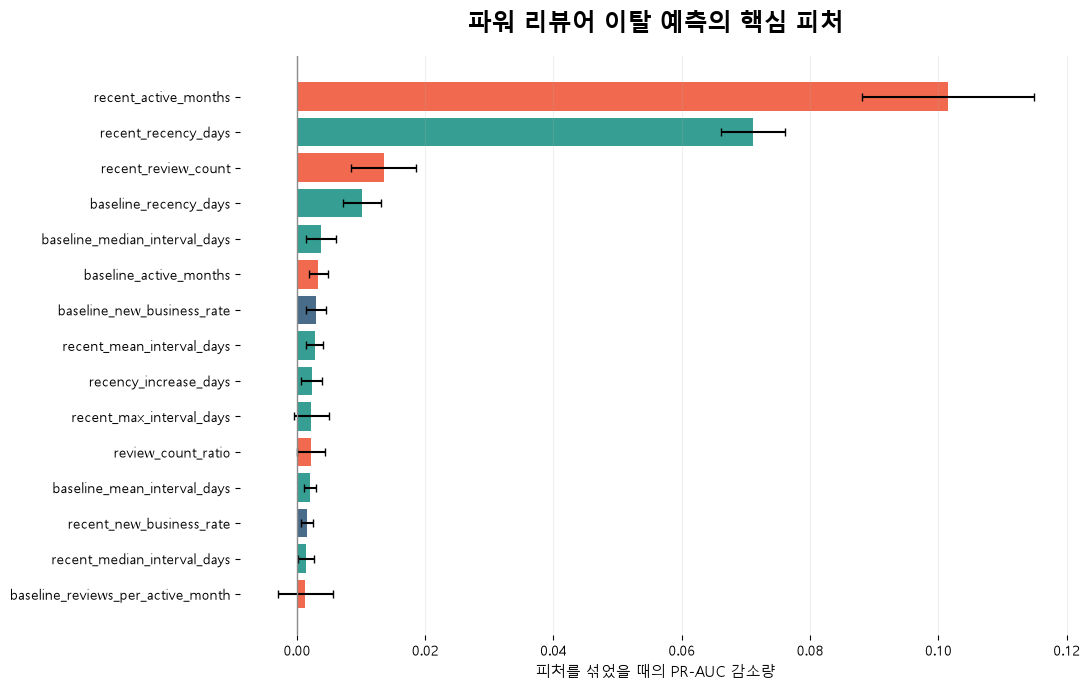

In [74]:
# 26. 상위 15개 피처 중요도 그래프

top_feature_importance_df = (
    feature_importance_df
    .head(15)
    .sort_values(
        "importance_mean",
        ascending=True
    )
)

group_color_map = {
    "activity":
        "#F05A3C",

    "interval":
        "#209486",

    "business":
        "#355C7D"
}

bar_colors = (
    top_feature_importance_df[
        "feature_group"
    ].map(
        group_color_map
    )
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.barh(
    top_feature_importance_df[
        "feature"
    ],
    top_feature_importance_df[
        "importance_mean"
    ],
    xerr=top_feature_importance_df[
        "importance_std"
    ],
    color=bar_colors,
    alpha=0.9,
    capsize=3
)

ax.axvline(
    0,
    color="#8B8B8B",
    linewidth=1
)

ax.set_title(
    "파워 리뷰어 이탈 예측의 핵심 피처",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "피처를 섞었을 때의 PR-AUC 감소량",
    fontsize=11
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.2
)

sns.despine(
    ax=ax,
    left=True,
    bottom=True
)

plt.tight_layout()

plt.savefig(
    FEATURE_IMPORTANCE_FIGURE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

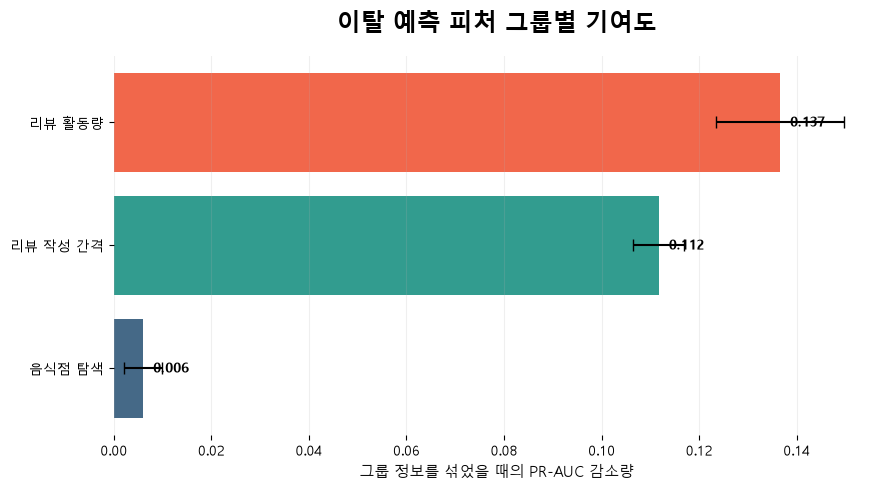

In [75]:
# 27. 그룹별 중요도 그래프

group_plot_df = (
    feature_group_importance_df
    .sort_values(
        "importance_mean",
        ascending=True
    )
)

group_bar_colors = (
    group_plot_df[
        "feature_group"
    ].map(
        group_color_map
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.barh(
    group_plot_df[
        "feature_group_label"
    ],
    group_plot_df[
        "importance_mean"
    ],
    xerr=group_plot_df[
        "importance_std"
    ],
    color=group_bar_colors,
    alpha=0.92,
    capsize=4
)

ax.set_title(
    "이탈 예측 피처 그룹별 기여도",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "그룹 정보를 섞었을 때의 PR-AUC 감소량",
    fontsize=11
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.2
)

for bar in bars:

    importance_value = (
        bar.get_width()
    )

    ax.text(
        importance_value + 0.002,
        bar.get_y()
        + bar.get_height() / 2,
        f"{importance_value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

sns.despine(
    ax=ax,
    left=True,
    bottom=True
)

plt.tight_layout()

plt.savefig(
    FEATURE_GROUP_FIGURE_PATH,
    dpi=220,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [76]:
# 28. 피처 중요도 결과 저장

feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False,
    encoding="utf-8-sig"
)

feature_group_importance_df.to_csv(
    FEATURE_GROUP_IMPORTANCE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "개별 피처 중요도:",
    FEATURE_IMPORTANCE_PATH
)

print(
    "그룹 피처 중요도:",
    FEATURE_GROUP_IMPORTANCE_PATH
)

print(
    "개별 피처 그래프:",
    FEATURE_IMPORTANCE_FIGURE_PATH
)

print(
    "그룹 중요도 그래프:",
    FEATURE_GROUP_FIGURE_PATH
)

개별 피처 중요도: C:\Users\playdata2\SKN34-2nd-5Team\reports\tables\final_feature_importance_v02.csv
그룹 피처 중요도: C:\Users\playdata2\SKN34-2nd-5Team\reports\tables\final_feature_group_importance_v02.csv
개별 피처 그래프: C:\Users\playdata2\SKN34-2nd-5Team\reports\figures\final_feature_importance_v02.png
그룹 중요도 그래프: C:\Users\playdata2\SKN34-2nd-5Team\reports\figures\final_feature_group_importance_v02.png


In [77]:
# 29. 최종 위험 점수 데이터 준비

FINAL_TEST_RANKING_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "predictions"
    / "final_test_risk_scores_v02.parquet"
)

if "test_ranking_df" not in globals():

    test_ranking_df = pd.read_parquet(
        FINAL_TEST_RANKING_PATH
    )

test_ranking_df = (
    test_ranking_df
    .sort_values(
        [
            "risk_score",
            "sample_id"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

print(
    "위험 점수 사용자:",
    len(test_ranking_df)
)

display(
    test_ranking_df.head()
)

위험 점수 사용자: 4157


,sample_id,user_id,selection_year,observation_year,target_year,churn,risk_score,selected_for_crm
0,xaW3eCvr5EGGjBc2Y9t2fA_2017,xaW3eCvr5EGGjBc2Y9t2fA,2017,2018,2019,0,0.846537,1
1,D1PjyzlSaA3tXRrADZCi_g_2017,D1PjyzlSaA3tXRrADZCi_g,2017,2018,2019,1,0.844245,1
2,rEyyY6KyocJ4Ug3z7LNeSQ_2017,rEyyY6KyocJ4Ug3z7LNeSQ,2017,2018,2019,1,0.844245,1
3,VCcsReAavmpOLJTK22yJGw_2017,VCcsReAavmpOLJTK22yJGw,2017,2018,2019,1,0.842336,1
4,hBWo_vjrlwrG75dIVr48Qw_2017,hBWo_vjrlwrG75dIVr48Qw,2017,2018,2019,0,0.841833,1


In [78]:
# 30. 위험 순위·백분위 계산

risk_user_count = len(
    test_ranking_df
)

test_ranking_df[
    "risk_rank"
] = (
    np.arange(
        1,
        risk_user_count + 1
    )
)

# 상위 몇 %에 해당하는지
# 값이 작을수록 위험 순위가 높음
test_ranking_df[
    "risk_top_percent"
] = (
    test_ranking_df[
        "risk_rank"
    ]
    / risk_user_count
    * 100
)

# 일반적인 백분위 점수
# 값이 클수록 위험 순위가 높음
test_ranking_df[
    "risk_percentile"
] = (
    (
        risk_user_count
        - test_ranking_df[
            "risk_rank"
        ]
        + 1
    )
    / risk_user_count
    * 100
)

display(
    test_ranking_df[
        [
            "user_id",
            "risk_score",
            "risk_rank",
            "risk_top_percent",
            "risk_percentile"
        ]
    ].head(10)
)

,user_id,risk_score,risk_rank,risk_top_percent,risk_percentile
0,xaW3eCvr5EGGjBc2Y9t2fA,0.846537,1,0.024056,100.000000
1,D1PjyzlSaA3tXRrADZCi_g,0.844245,2,0.048112,99.975944
2,rEyyY6KyocJ4Ug3z7LNeSQ,0.844245,3,0.072167,99.951888
3,VCcsReAavmpOLJTK22yJGw,0.842336,4,0.096223,99.927833
4,hBWo_vjrlwrG75dIVr48Qw,0.841833,5,0.120279,99.903777
5,_VeX3JLDQ9qJmfEc2-mLJA,0.838628,6,0.144335,99.879721
6,UfgkQmFpbyCa0x4KjhMFcg,0.837840,7,0.168391,99.855665
7,tWUGf_cDJXecdq2N3-y63w,0.837521,8,0.192446,99.831609
8,AVpGpYN21Q_uY0O_FAU31Q,0.836323,9,0.216502,99.807554
9,YAgYJepLltKbvr7xGxTSzQ,0.836323,10,0.240558,99.783498


In [79]:
# 31. 위험 등급별 인원 기준

critical_user_count = int(
    np.ceil(
        risk_user_count * 0.05
    )
)

crm_target_user_count = int(
    np.ceil(
        risk_user_count * 0.20
    )
)

watch_user_count = int(
    np.ceil(
        risk_user_count * 0.40
    )
)

print(
    "긴급 관리:",
    critical_user_count
)

print(
    "전체 CRM 대상:",
    crm_target_user_count
)

print(
    "관찰 대상 포함:",
    watch_user_count
)

긴급 관리: 208
전체 CRM 대상: 832
관찰 대상 포함: 1663


In [81]:
# 32. 위험 등급 부여

test_ranking_df[
    "risk_tier"
] = np.select(
    [
        test_ranking_df[
            "risk_rank"
        ] <= critical_user_count,

        test_ranking_df[
            "risk_rank"
        ] <= crm_target_user_count,

        test_ranking_df[
            "risk_rank"
        ] <= watch_user_count
    ],
    [
        "긴급 관리",
        "집중 관리",
        "관찰 대상"
    ],
    default="일반"
)

# 긴급 관리와 집중 관리가 최종 CRM 대상
test_ranking_df[
    "crm_target"
] = (
    test_ranking_df[
        "risk_rank"
    ] <= crm_target_user_count
).astype("int8")

test_ranking_df[
    "crm_target_label"
] = np.where(
    test_ranking_df[
        "crm_target"
    ].eq(1),
    "CRM 개입 대상",
    "일반 운영"
)

# Test 데이터에서만 사용할 검증용 실제 결과
test_ranking_df[
    "actual_result"
] = (
    test_ranking_df[
        "churn"
    ].map({
        0: "유지",
        1: "이탈"
    })
)

In [82]:
# 33. 사용자별 상세 화면에 표시할 핵심 피처

reviewer_display_features = [
    # 활동량
    "baseline_review_count",
    "recent_review_count",
    "review_count_decline_rate",

    "baseline_active_months",
    "recent_active_months",
    "active_month_decline_rate",

    # 작성 간격
    "baseline_recency_days",
    "recent_recency_days",
    "recency_increase_days",

    "baseline_mean_interval_days",
    "recent_mean_interval_days",
    "mean_interval_increase_days",
    "recent_interval_available",

    # 음식점 탐색
    "baseline_unique_business_count",
    "recent_unique_business_count",
    "unique_business_decline_rate",

    "baseline_new_business_rate",
    "recent_new_business_rate",
    "new_business_rate_decline",

    "recent_revisit_rate"
]

missing_display_features = (
    set(reviewer_display_features)
    - set(modeling_df.columns)
)

assert not missing_display_features, (
    f"Reviewer Explorer 피처 누락: "
    f"{missing_display_features}"
)

In [83]:
# 34. 위험 점수와 주요 피처 결합

reviewer_risk_profile_df = (
    test_ranking_df
    .merge(
        modeling_df[
            [
                "sample_id",
                *reviewer_display_features
            ]
        ],
        on="sample_id",
        how="left",
        validate="one_to_one"
    )
)

print(
    "Reviewer Explorer 데이터:",
    reviewer_risk_profile_df.shape
)

assert reviewer_risk_profile_df[
    "sample_id"
].is_unique

assert reviewer_risk_profile_df[
    "risk_tier"
].isna().sum() == 0

assert reviewer_risk_profile_df[
    "crm_target"
].sum() == (
    crm_target_user_count
)

Reviewer Explorer 데이터: (4157, 35)


In [84]:
# 35. 위험 등급 표시 순서

risk_tier_order = [
    "긴급 관리",
    "집중 관리",
    "관찰 대상",
    "일반"
]

reviewer_risk_profile_df[
    "risk_tier"
] = pd.Categorical(
    reviewer_risk_profile_df[
        "risk_tier"
    ],
    categories=risk_tier_order,
    ordered=True
)

In [85]:
# 36. 위험 등급별 사용자와 실제 이탈 집계

risk_tier_summary_df = (
    reviewer_risk_profile_df
    .groupby(
        "risk_tier",
        observed=True,
        as_index=False
    )
    .agg(
        users=(
            "sample_id",
            "size"
        ),
        churn_users=(
            "churn",
            "sum"
        ),
        observed_churn_rate=(
            "churn",
            "mean"
        ),
        mean_risk_score=(
            "risk_score",
            "mean"
        ),
        minimum_risk_score=(
            "risk_score",
            "min"
        ),
        maximum_risk_score=(
            "risk_score",
            "max"
        ),
        minimum_risk_percentile=(
            "risk_percentile",
            "min"
        ),
        maximum_risk_percentile=(
            "risk_percentile",
            "max"
        )
    )
)

total_churn_users = (
    reviewer_risk_profile_df[
        "churn"
    ].sum()
)

risk_tier_summary_df[
    "user_rate"
] = (
    risk_tier_summary_df[
        "users"
    ]
    / len(
        reviewer_risk_profile_df
    )
)

risk_tier_summary_df[
    "captured_churn_rate"
] = (
    risk_tier_summary_df[
        "churn_users"
    ]
    / total_churn_users
)

overall_churn_rate = (
    reviewer_risk_profile_df[
        "churn"
    ].mean()
)

risk_tier_summary_df[
    "lift"
] = (
    risk_tier_summary_df[
        "observed_churn_rate"
    ]
    / overall_churn_rate
)

display(
    risk_tier_summary_df.round(4)
)

,risk_tier,users,churn_users,observed_churn_rate,mean_risk_score,minimum_risk_score,maximum_risk_score,minimum_risk_percentile,maximum_risk_percentile,user_rate,captured_churn_rate,lift
0,긴급 관리,208,112,0.5385,0.8047,0.7790,0.8465,95.0204,100.0000,0.0500,0.1672,3.3409
1,집중 관리,624,234,0.3750,0.7215,0.6579,0.7786,80.0096,94.9964,0.1501,0.3493,2.3267
2,관찰 대상,831,185,0.2226,0.5418,0.4110,0.6574,60.0192,79.9856,0.1999,0.2761,1.3813
3,일반,2494,139,0.0557,0.1703,0.0232,0.4109,0.0241,59.9952,0.6000,0.2075,0.3458


In [86]:
# 37. Streamlit이 읽을 위험 정책 정보

risk_policy_metadata = {
    "policy_name":
        "파워 리뷰어 상위 위험군 CRM 정책",

    "score_type":
        "uncalibrated_risk_score",

    "score_warning":
        (
            "위험 점수는 확률 보정 전 점수이며 "
            "실제 이탈 확률로 해석하지 않는다."
        ),

    "primary_target_rate":
        0.20,

    "tiers": [
        {
            "tier":
                "긴급 관리",
            "rank_range":
                "상위 5%",
            "crm_target":
                True,
            "recommended_action":
                "Elite 혜택·행사 초대·개인화 리텐션"
        },
        {
            "tier":
                "집중 관리",
            "rank_range":
                "상위 5~20%",
            "crm_target":
                True,
            "recommended_action":
                "맞춤 미션·신규 맛집 추천·활동 리포트"
        },
        {
            "tier":
                "관찰 대상",
            "rank_range":
                "상위 20~40%",
            "crm_target":
                False,
            "recommended_action":
                "저비용 알림·콘텐츠 추천"
        },
        {
            "tier":
                "일반",
            "rank_range":
                "하위 60%",
            "crm_target":
                False,
            "recommended_action":
                "일반 운영"
        }
    ]
}

In [87]:
# 38. 위험 등급 데이터 저장 경로

RISK_PROFILE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "predictions"
    / "final_reviewer_risk_profiles_v02.parquet"
)

RISK_TIER_SUMMARY_PATH = (
    REPORT_TABLE_DIR
    / "final_risk_tier_summary_v02.csv"
)

RISK_POLICY_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "predictions"
    / "risk_policy_v02.json"
)

In [88]:
# 40. 결정 문서와 모델링 보고서 저장 폴더

DECISION_DIR = (
    PROJECT_ROOT
    / "docs"
    / "decisions"
)

MODELING_REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "modeling"
)

DECISION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODELING_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [89]:
# 41. 최종 모델 선정 결정 문서

DEC_005_PATH = (
    DECISION_DIR
    / "DEC-005_final_model_selection.md"
)

dec_005_content = """
# DEC-005. 최종 이탈 예측 모델 선정

- 상태: 팀 검토 예정
- 버전: v0.2
- 작성일: 2026-07-24
- 프로젝트: Yelp 파워 리뷰어의 미식 번아웃 예측

## 1. 결정 사항

파워 리뷰어 이탈 위험 예측의 프로토타입 모델로 다음 구성을 선정한다.

- 문제 유형: 지도학습 이진 분류
- 모델: HistGradientBoostingClassifier
- 피처 구성: Core 43개
- 핵심 피처 그룹:
  - 리뷰 활동량
  - 리뷰 작성 간격
  - 음식점 탐색
- 모델 선택 기준: Validation PR-AUC
- 최종 학습 범위: 선정연도 2009~2016
- 최종 Test: 선정연도 2017, 타깃연도 2019

## 2. 이탈 정의

선정연도와 관찰연도에 파워 리뷰어 조건을 만족한 사용자가
그다음 타깃연도에 음식 관련 리뷰를 한 건도 작성하지 않은 경우를
이탈로 정의한다.

- churn = 1: 타깃연도 리뷰 0건
- churn = 0: 타깃연도 리뷰 1건 이상

## 3. 데이터 범위

- 분석 범위: Restaurants + 미식 방문형 업체
- 음식점·미식 관련 업체: 58,156개
- 음식 관련 리뷰: 4,950,264건
- 롤링 사용자-연도 표본: 21,601개
- 전체 이탈 표본: 3,386개
- 전체 이탈률: 약 15.7%

미식 방문형 범위에는 카페, 커피·차, 디저트, 베이커리,
아이스크림, 도넛, 주스·스무디, 푸드트럭 등이 포함된다.

## 4. 모델 비교 결과

Validation 선정연도는 2016년, 타깃연도는 2018년이다.

| 모델 | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|
| HistGradientBoosting | 0.3173 | 0.7514 | 0.4462 | 0.8156 | 0.3991 |
| LogisticRegression | 0.3029 | 0.7875 | 0.4375 | 0.8116 | 0.3817 |
| RandomForest | 0.4354 | 0.2941 | 0.3511 | 0.8096 | 0.3775 |
| DummyClassifier | 0.0000 | 0.0000 | 0.0000 | 0.5000 | 0.1415 |

HistGradientBoosting이 가장 높은 PR-AUC와 F1을 보여
최종 후보로 선정됐다.

## 5. 피처 구성 결정

| 피처 조합 | 피처 수 | Validation PR-AUC |
|---|---:|---:|
| 활동량 | 15 | 0.3600 |
| 활동량 + 작성 간격 | 28 | 0.3873 |
| Core: 활동량 + 작성 간격 + 음식점 탐색 | 43 | 0.4032 |
| Core + 카테고리 | 57 | 0.3854 |
| Core + 탐방 반경 | 55 | 0.3986 |
| Core + 평점 | 55 | 0.3970 |
| 전체 피처 | 81 | 0.3991 |

Core 43개 피처가 가장 높은 PR-AUC를 기록했다.

카테고리 다양성, 탐방 반경, 평점 변화에서는 이탈 집단 간
차이가 관찰됐지만 Core 피처에 추가했을 때 순위 성능 개선은
제한적이었다.

따라서 해당 피처는 분석·설명용으로 유지하되 현재 프로토타입
모델 입력에서는 제외한다.

## 6. 튜닝 모델 제외 근거

| 모델 | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|
| 기본 Core HGB | 0.3107 | 0.7476 | 0.4390 | 0.8146 | 0.4032 |
| 튜닝 Core HGB | 0.3101 | 0.7609 | 0.4407 | 0.8147 | 0.4015 |

튜닝 모델은 Recall과 F1이 소폭 상승했지만 PR-AUC가 하락했다.
Recall 차이는 운영 임계값으로 조정할 수 있으므로 더 단순한
기본 HGB 설정을 유지한다.

## 7. 피처 중요도 결과

최종 Test Permutation Importance 상위 피처는 다음과 같다.

1. recent_active_months
2. recent_recency_days
3. recent_review_count
4. baseline_recency_days
5. baseline_median_interval_days

그룹 중요도는 다음 순서로 나타났다.

1. 리뷰 활동량
2. 리뷰 작성 간격
3. 음식점 탐색

따라서 단순 리뷰 수 감소보다 최근 활동 지속성과 마지막 리뷰 이후
경과 기간이 핵심 이탈 신호인 것으로 판단한다.

## 8. 결과 해석

본 모델은 사용자의 실제 생활 전체나 의학적 번아웃을 측정하지 않는다.

본 프로젝트에서 사용하는 미식 번아웃은 다음 현상을 설명하는
운영 목적의 표현이다.

- 리뷰 활동 월수 감소
- 리뷰 작성 간격 증가
- 마지막 리뷰 이후 경과 기간 증가
- 고유 음식점 탐색 감소
- 신규 음식점 탐색 감소

## 9. 변경 조건

다음 조건이 변경되면 본 결정을 재검토한다.

- 파워 리뷰어 선정 기준
- 음식 관련 업체 범위
- 이탈 정의
- 관찰 기간과 타깃 기간
- 팀 미팅 후 모델 목표
- 실제 CRM 비용과 개입 가능 인원
"""

DEC_005_PATH.write_text(
    dec_005_content.strip() + "\n",
    encoding="utf-8"
)

print(
    "생성 완료:",
    DEC_005_PATH
)

생성 완료: C:\Users\playdata2\SKN34-2nd-5Team\docs\decisions\DEC-005_final_model_selection.md


In [90]:
# 42. CRM 타기팅 정책 결정 문서

DEC_006_PATH = (
    DECISION_DIR
    / "DEC-006_crm_targeting_policy.md"
)

dec_006_content = """
# DEC-006. 파워 리뷰어 CRM 타기팅 정책

- 상태: 팀 검토 예정
- 버전: v0.2
- 작성일: 2026-07-24
- 관련 결정: DEC-005 최종 이탈 예측 모델 선정

## 1. 결정 사항

파워 리뷰어 리텐션 프로토타입의 대표 운영 정책으로
위험 점수 상위 20%를 CRM 개입 대상으로 선정한다.

- 대표 타기팅 비율: 상위 20%
- 대상 등급: 긴급 관리 + 집중 관리
- 기준 지표: 위험 점수 순위
- 위험 점수 상태: 확률 보정 전
- 사용 금지 표현: 이탈 확률
- 권장 표현: 위험 점수, 위험 순위, 위험 등급

## 2. 위험 등급

| 위험 등급 | 위험 순위 | CRM 대상 | 권장 개입 |
|---|---:|---:|---|
| 긴급 관리 | 상위 5% | 대상 | Elite 혜택, 행사 초대, 개인화 리텐션 |
| 집중 관리 | 상위 5~20% | 대상 | 맞춤 미션, 신규 맛집 추천, 활동 리포트 |
| 관찰 대상 | 상위 20~40% | 비대상 | 저비용 알림, 콘텐츠 추천 |
| 일반 | 하위 60% | 비대상 | 일반 운영 |

## 3. 최종 Test 성능

최종 Test는 선정연도 2017년 표본을 사용해 2019년 이탈을 평가했다.

- 전체 사용자: 4,157명
- 실제 이탈자: 670명
- 상위 20% 타기팅 사용자: 832명
- 포착한 실제 이탈자: 346명
- Precision@20%: 41.59%
- Recall@20%: 51.64%
- Lift@20%: 2.58배

전체 사용자의 20%에 개입해 실제 이탈자의 51.64%를 포착했다.
타기팅 집단의 이탈률은 전체 평균보다 2.58배 높았다.

## 4. 등급별 Test 결과

| 위험 등급 | 사용자 | 실제 이탈자 | 이탈률 | Lift |
|---|---:|---:|---:|---:|
| 긴급 관리 | 208 | 112 | 53.85% | 3.34배 |
| 집중 관리 | 624 | 234 | 37.50% | 2.33배 |
| 관찰 대상 | 831 | 185 | 22.26% | 1.38배 |
| 일반 | 2,494 | 139 | 5.57% | 0.35배 |

위험 등급이 낮아질수록 실제 이탈률도 일관되게 낮아졌다.

## 5. 운영 시나리오

### 긴급 관리

고비용이지만 강한 개인화가 가능한 개입을 적용한다.

- 신규 맛집 우선 체험
- 지역 미식 행사 초대
- Elite 혜택 유지
- 개인화 활동 리포트
- 전담 커뮤니티 미션

### 집중 관리

비교적 확장 가능한 리텐션 개입을 적용한다.

- 미방문 음식점 추천
- 지역별 탐방 미션
- 작성 부담이 적은 리뷰 형식 제안
- 활동 배지
- 리뷰 반응 알림

### 관찰 대상

저비용 채널 중심으로 관리한다.

- 푸시 알림
- 신규 맛집 콘텐츠
- 지역 인기 리뷰
- 주간 활동 요약

## 6. 위험 점수 해석 제한

현재 predict_proba 출력은 class_weight가 적용된 모델의
확률 보정 전 점수다.

따라서 다음 표현을 사용하지 않는다.

- 이 사용자의 이탈 확률은 78%입니다.

대신 다음처럼 표현한다.

- 위험 점수: 0.78
- 위험 순위: 상위 4.2%
- 위험 등급: 긴급 관리
- CRM 개입 대상: 대상

향후 실제 확률이 필요하면 별도의 확률 보정과 Calibration 평가를
수행해야 한다.

## 7. 정책 변경 조건

다음 정보가 확보되면 상위 20% 기준을 다시 검토할 수 있다.

- 사용자 한 명당 개입 비용
- 이탈 방어 성공으로 얻는 기대 가치
- 월간 CRM 처리 가능 인원
- 개입 유형별 성공률
- 위험 등급별 실험 결과
"""

DEC_006_PATH.write_text(
    dec_006_content.strip() + "\n",
    encoding="utf-8"
)

print(
    "생성 완료:",
    DEC_006_PATH
)

생성 완료: C:\Users\playdata2\SKN34-2nd-5Team\docs\decisions\DEC-006_crm_targeting_policy.md


In [91]:
# 43. 최종 모델 성능 보고서

FINAL_PERFORMANCE_REPORT_PATH = (
    MODELING_REPORT_DIR
    / "final_model_performance.md"
)

final_performance_content = """
# Yelp 파워 리뷰어 이탈 예측 최종 모델 성능

- 보고서 버전: v0.2
- 작성일: 2026-07-24
- 상태: 프로토타입·팀 검토 예정

## 1. 모델 목적

최근 음식점 리뷰 활동 변화를 기반으로 다음 연도에 음식 관련
리뷰 활동을 중단할 가능성이 높은 파워 리뷰어를 선별한다.

모델의 목적은 모든 사용자의 결과를 완벽하게 맞히는 것이 아니라
제한된 CRM 자원을 이탈 위험이 높은 사용자에게 집중하는 것이다.

## 2. 최종 모델

- 모델: HistGradientBoostingClassifier
- 피처: Core 43개
- 피처 그룹:
  - 리뷰 활동량
  - 리뷰 작성 간격
  - 음식점 탐색
- 최종 Train: 선정연도 2009~2016
- 최종 Test: 선정연도 2017
- Test 타깃: 2019년 이탈 여부
- 운영 정책: 위험 점수 상위 20%

## 3. Validation·Test 성능

| 데이터 | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|
| Validation | 0.3107 | 0.7476 | 0.4390 | 0.8146 | 0.4032 |
| Test | 0.3436 | 0.7134 | 0.4639 | 0.8125 | 0.4264 |

Test에서도 ROC-AUC와 PR-AUC가 안정적으로 유지됐다.
따라서 특정 Validation 연도에만 과적합된 징후는 크지 않다.

## 4. Test Top-K 성능

| 대상 비율 | 대상 사용자 | 포착 이탈자 | Precision | Recall | Lift |
|---:|---:|---:|---:|---:|---:|
| 5% | 208 | 112 | 53.85% | 16.72% | 3.34배 |
| 10% | 416 | 202 | 48.56% | 30.15% | 3.01배 |
| 15% | 624 | 281 | 45.03% | 41.94% | 2.79배 |
| 20% | 832 | 346 | 41.59% | 51.64% | 2.58배 |
| 25% | 1,040 | 397 | 38.17% | 59.25% | 2.37배 |
| 30% | 1,248 | 448 | 35.90% | 66.87% | 2.23배 |
| 35% | 1,455 | 490 | 33.68% | 73.13% | 2.09배 |
| 40% | 1,663 | 531 | 31.93% | 79.25% | 1.98배 |

대표 정책인 상위 20%에서는 전체 이탈자의 51.64%를 포착했다.

## 5. 주요 예측 신호

개별 피처 중요도 상위 신호:

1. 최근 활동 월수
2. 마지막 리뷰 이후 경과일
3. 최근 리뷰 수
4. 기존 마지막 리뷰 이후 경과일
5. 기존 리뷰 작성 간격 중앙값

그룹 중요도:

| 피처 그룹 | PR-AUC 감소량 |
|---|---:|
| 리뷰 활동량 | 0.13656 |
| 리뷰 작성 간격 | 0.11170 |
| 음식점 탐색 | 0.00600 |

파워 리뷰어 이탈은 리뷰 수 감소뿐 아니라 활동 지속성 감소와
마지막 리뷰 이후 경과 기간 증가에서 강하게 나타났다.

## 6. 비즈니스 적용

- 위험 상위 5%: 고비용 개인화 리텐션
- 위험 상위 5~20%: 일반 CRM 개입
- 위험 상위 20~40%: 저비용 관찰·알림
- 하위 60%: 일반 운영

지역·카테고리 단위로 위험 사용자를 집계하면 콘텐츠 공급 부족
지역을 사전에 파악하는 운영 지표로 확장할 수 있다.

## 7. 한계

- Yelp 데이터는 사용자의 실제 생활 전체를 나타내지 않는다.
- 미식 번아웃은 의학적 상태가 아니라 리뷰 활동 감소를 설명하는 표현이다.
- 위험 점수는 아직 실제 이탈 확률로 보정되지 않았다.
- 동일 사용자가 여러 선정연도의 롤링 표본에 포함될 수 있다.
- 음식점 탐색 피처는 활동량·작성 간격보다 추가 기여도가 작다.
- 2020년 이후는 코로나19로 인해 현재 학습 범위에서 제외했다.

## 8. 향후 과제

- 확률 보정
- FP·FN 오류 분석
- 사용자 비중복 민감도 실험
- 지역·카테고리별 콘텐츠 공급 위험 분석
- CRM 개입 비용을 반영한 최적 대상 비율 산정
- MLP 모델 비교 실험
"""

FINAL_PERFORMANCE_REPORT_PATH.write_text(
    final_performance_content.strip() + "\n",
    encoding="utf-8"
)

print(
    "생성 완료:",
    FINAL_PERFORMANCE_REPORT_PATH
)

생성 완료: C:\Users\playdata2\SKN34-2nd-5Team\reports\modeling\final_model_performance.md


In [92]:
# 44. 문서 생성 검증

document_validation_df = pd.DataFrame({
    "document": [
        "DEC-005 최종 모델 선정",
        "DEC-006 CRM 정책",
        "최종 모델 성능 보고서"
    ],
    "path": [
        str(DEC_005_PATH),
        str(DEC_006_PATH),
        str(
            FINAL_PERFORMANCE_REPORT_PATH
        )
    ],
    "exists": [
        DEC_005_PATH.exists(),
        DEC_006_PATH.exists(),
        FINAL_PERFORMANCE_REPORT_PATH.exists()
    ]
})

display(
    document_validation_df
)

assert document_validation_df[
    "exists"
].all()

,document,path,exists
0,DEC-005 최종 모델 선정,C:\Users\playdata2\SKN34-2nd-5Team\docs\decisi...,True
1,DEC-006 CRM 정책,C:\Users\playdata2\SKN34-2nd-5Team\docs\decisi...,True
2,최종 모델 성능 보고서,C:\Users\playdata2\SKN34-2nd-5Team\reports\mod...,True
